In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
u_neutral = mda.Universe("../Neutral-without-calcium.gro","../Neutral-without-Calcium.xtc")
u_neutral_ca = mda.Universe("../Neutral-with-Ca.gro","../Neutral-with-Ca.xtc")

u_two = mda.Universe("../+2-without-calcium.gro","../+2-without-calcium.xtc")
u_two_ca = mda.Universe("../+2-with-Ca.gro","../+2-with-Ca.xtc")

u_four = mda.Universe("../+4-without-calcium.gro","../+4-without-calcium.xtc")
u_four_ca = mda.Universe("../+4-with-Ca.gro","../+4-with-Ca.xtc")

u_five = mda.Universe("../+5-without-calcium.gro","../+5-without-calcium.xtc")
u_five_ca = mda.Universe("../+5-with-Ca.gro","../+5-with-Ca.xtc")

In [37]:
k = u_neutral.select_atoms("resid 8 and resname ASN and name CA")
print(k.positions)

[[35.72     36.210003 28.850002]]


In [3]:
selection = "resname TIP3 and prop z<54 and prop z>27 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"

In [23]:
def calculate_water(u, dataframe_name,selection):
    x = np.zeros(len(u.trajectory))
    y=np.zeros(len(u.trajectory))
    i=0
    for ts in u.trajectory:
        cw = u.select_atoms(selection)
        y[i] = cw.n_atoms/3
        x[i] = ts.frame /10
        i = i+1
    dataframe = pd.DataFrame({'Timeframe': x, 'Water molecules': y})
    dataframe.to_csv(dataframe_name + '.csv', index=False)
    return dataframe

In [19]:
def plot_water_molecules(df1, df2, save_name):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    plt.plot(df1['Timeframe'][:5000], df1['Water molecules'][:5000], color="blue", alpha=0.15)
    rolling_avg_df1 = df1['Water molecules'].rolling(window=50).mean()
    rolling_avg_df2 = df2['Water molecules'].rolling(window=50).mean()
    plt.plot(df1['Timeframe'][:5000], rolling_avg_df1[:5000], color="blue", label=r"without Ca$^{2+}$")
    plt.plot(df2['Timeframe'][:5000], df2['Water molecules'][:5000], color="red", alpha=0.15)
    plt.plot(df2['Timeframe'][:5000], rolling_avg_df2[:5000], color="red", label=r"with Ca$^{2+}$")
    ax.set_xlabel("Time (ns)", fontsize=22)
    plt.xticks(fontsize=20)
    ax.set_ylabel("Number of Water Molecules", fontsize=22)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.legend(fontsize=20)
    plt.savefig(save_name, dpi=300)
    plt.show()

In [85]:
df_neutral = calculate_water(u_neutral,'df_neutral')
#df_neutral_ca = calculate_water(u_neutral_ca,'df_neutral_ca')

In [76]:
df_neutral_ca.to_csv('df_neutral_ca.csv', index=False)
df_neutral.to_csv('df_neutral.csv',index=False)

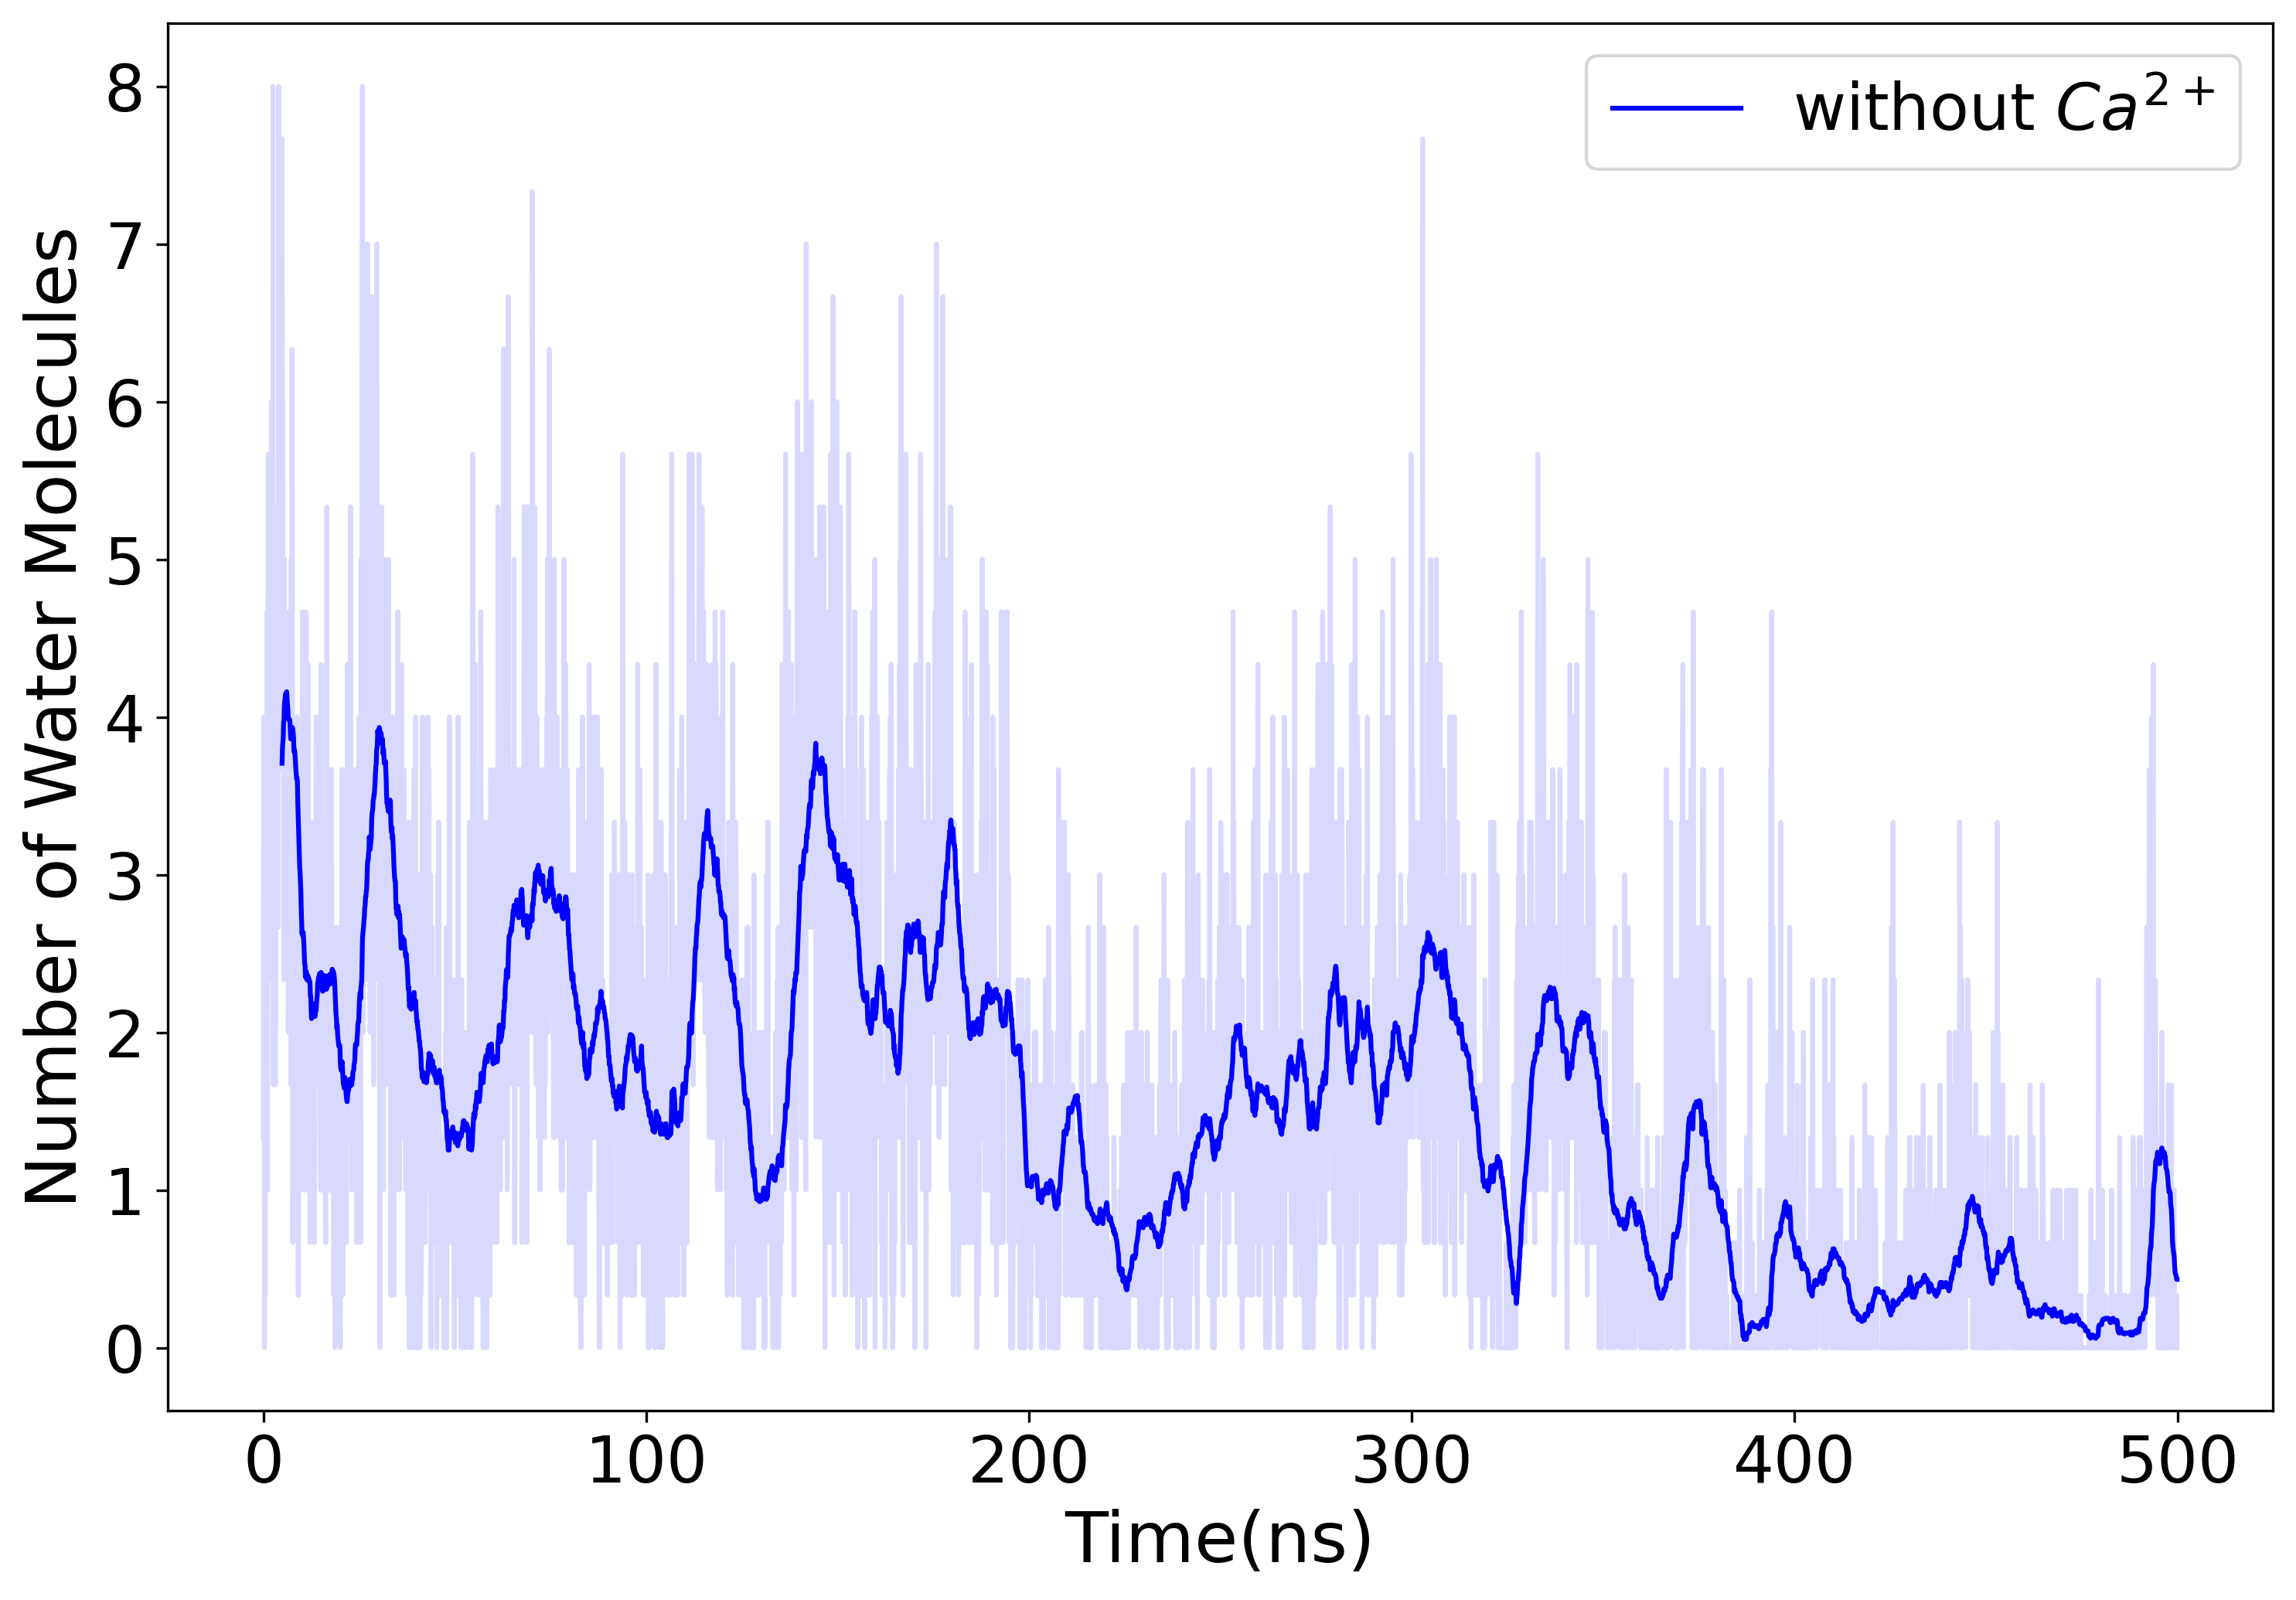

In [86]:
#plt.plot(df_neutral['Timeframe'],df_neutral['Water molecules'])
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_neutral['Timeframe'][:5000],df_neutral['Water molecules'][:5000],color="blue",alpha=0.15)
rolling_avg = df_neutral['Water molecules'].rolling(window=50).mean()
#rolling_avg_ca = df_neutral_ca['Water molecules'].rolling(window=50).mean()
plt.plot(df_neutral['Timeframe'][:5000],rolling_avg[:5000],color="blue",label=r"without $Ca^{2+}$")
#plt.plot(df_neutral_ca['Timeframe'][:5000],df_neutral_ca['Water molecules'][:5000],color="red",alpha=0.15)
#plt.plot(df_neutral_ca['Timeframe'][:5000],rolling_avg_ca[:5000],color="red",label=r"with $Ca^{2+}$")
#plt.axis([0,i,0,max(y)])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.legend(fontsize=20)
#plt.savefig("Number of water molecules (Neutral-state) with Ca 500ns with 3A (rolling).pdf",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

In [88]:
print(np.mean(df_neutral['Water molecules']))

1.448110927786944


In [ ]:
df_neutral = pd.read_csv('dataframe_neutral.csv')
df_neutral_ca = pd.read_csv('dataframe_neutral_ca.csv')
plot_water_molecules(df_neutral, df_neutral_ca, "Number of water molecules with and without Ca (rolling).png")

NameError: name 'df_neutral_ca' is not defined

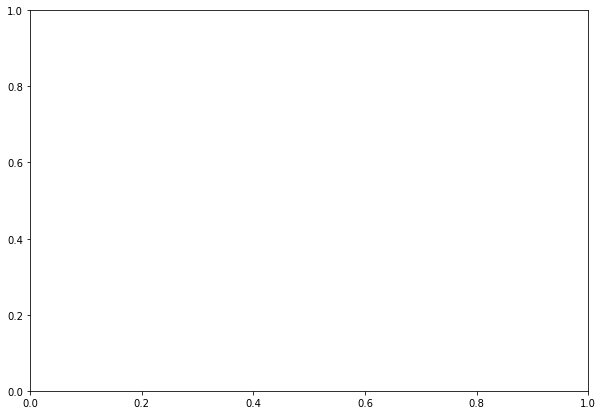

In [14]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_neutral_ca['Timeframe'][:5000],df_neutral_ca['Water molecules'][:5000])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (Neutral-state) with Ca 500ns with 3A.png",dpi=300)
plt.show()

In [56]:
selection = "resname TIP3 and prop z<55 and prop z>27 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"

selection_ca = "resname TIP3 and prop z<75 and prop z>47 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"

In [57]:
df_two = calculate_water(u_two,'df_two',selection)
df_two_ca = calculate_water(u_two_ca,'df_two_ca',selection_ca)

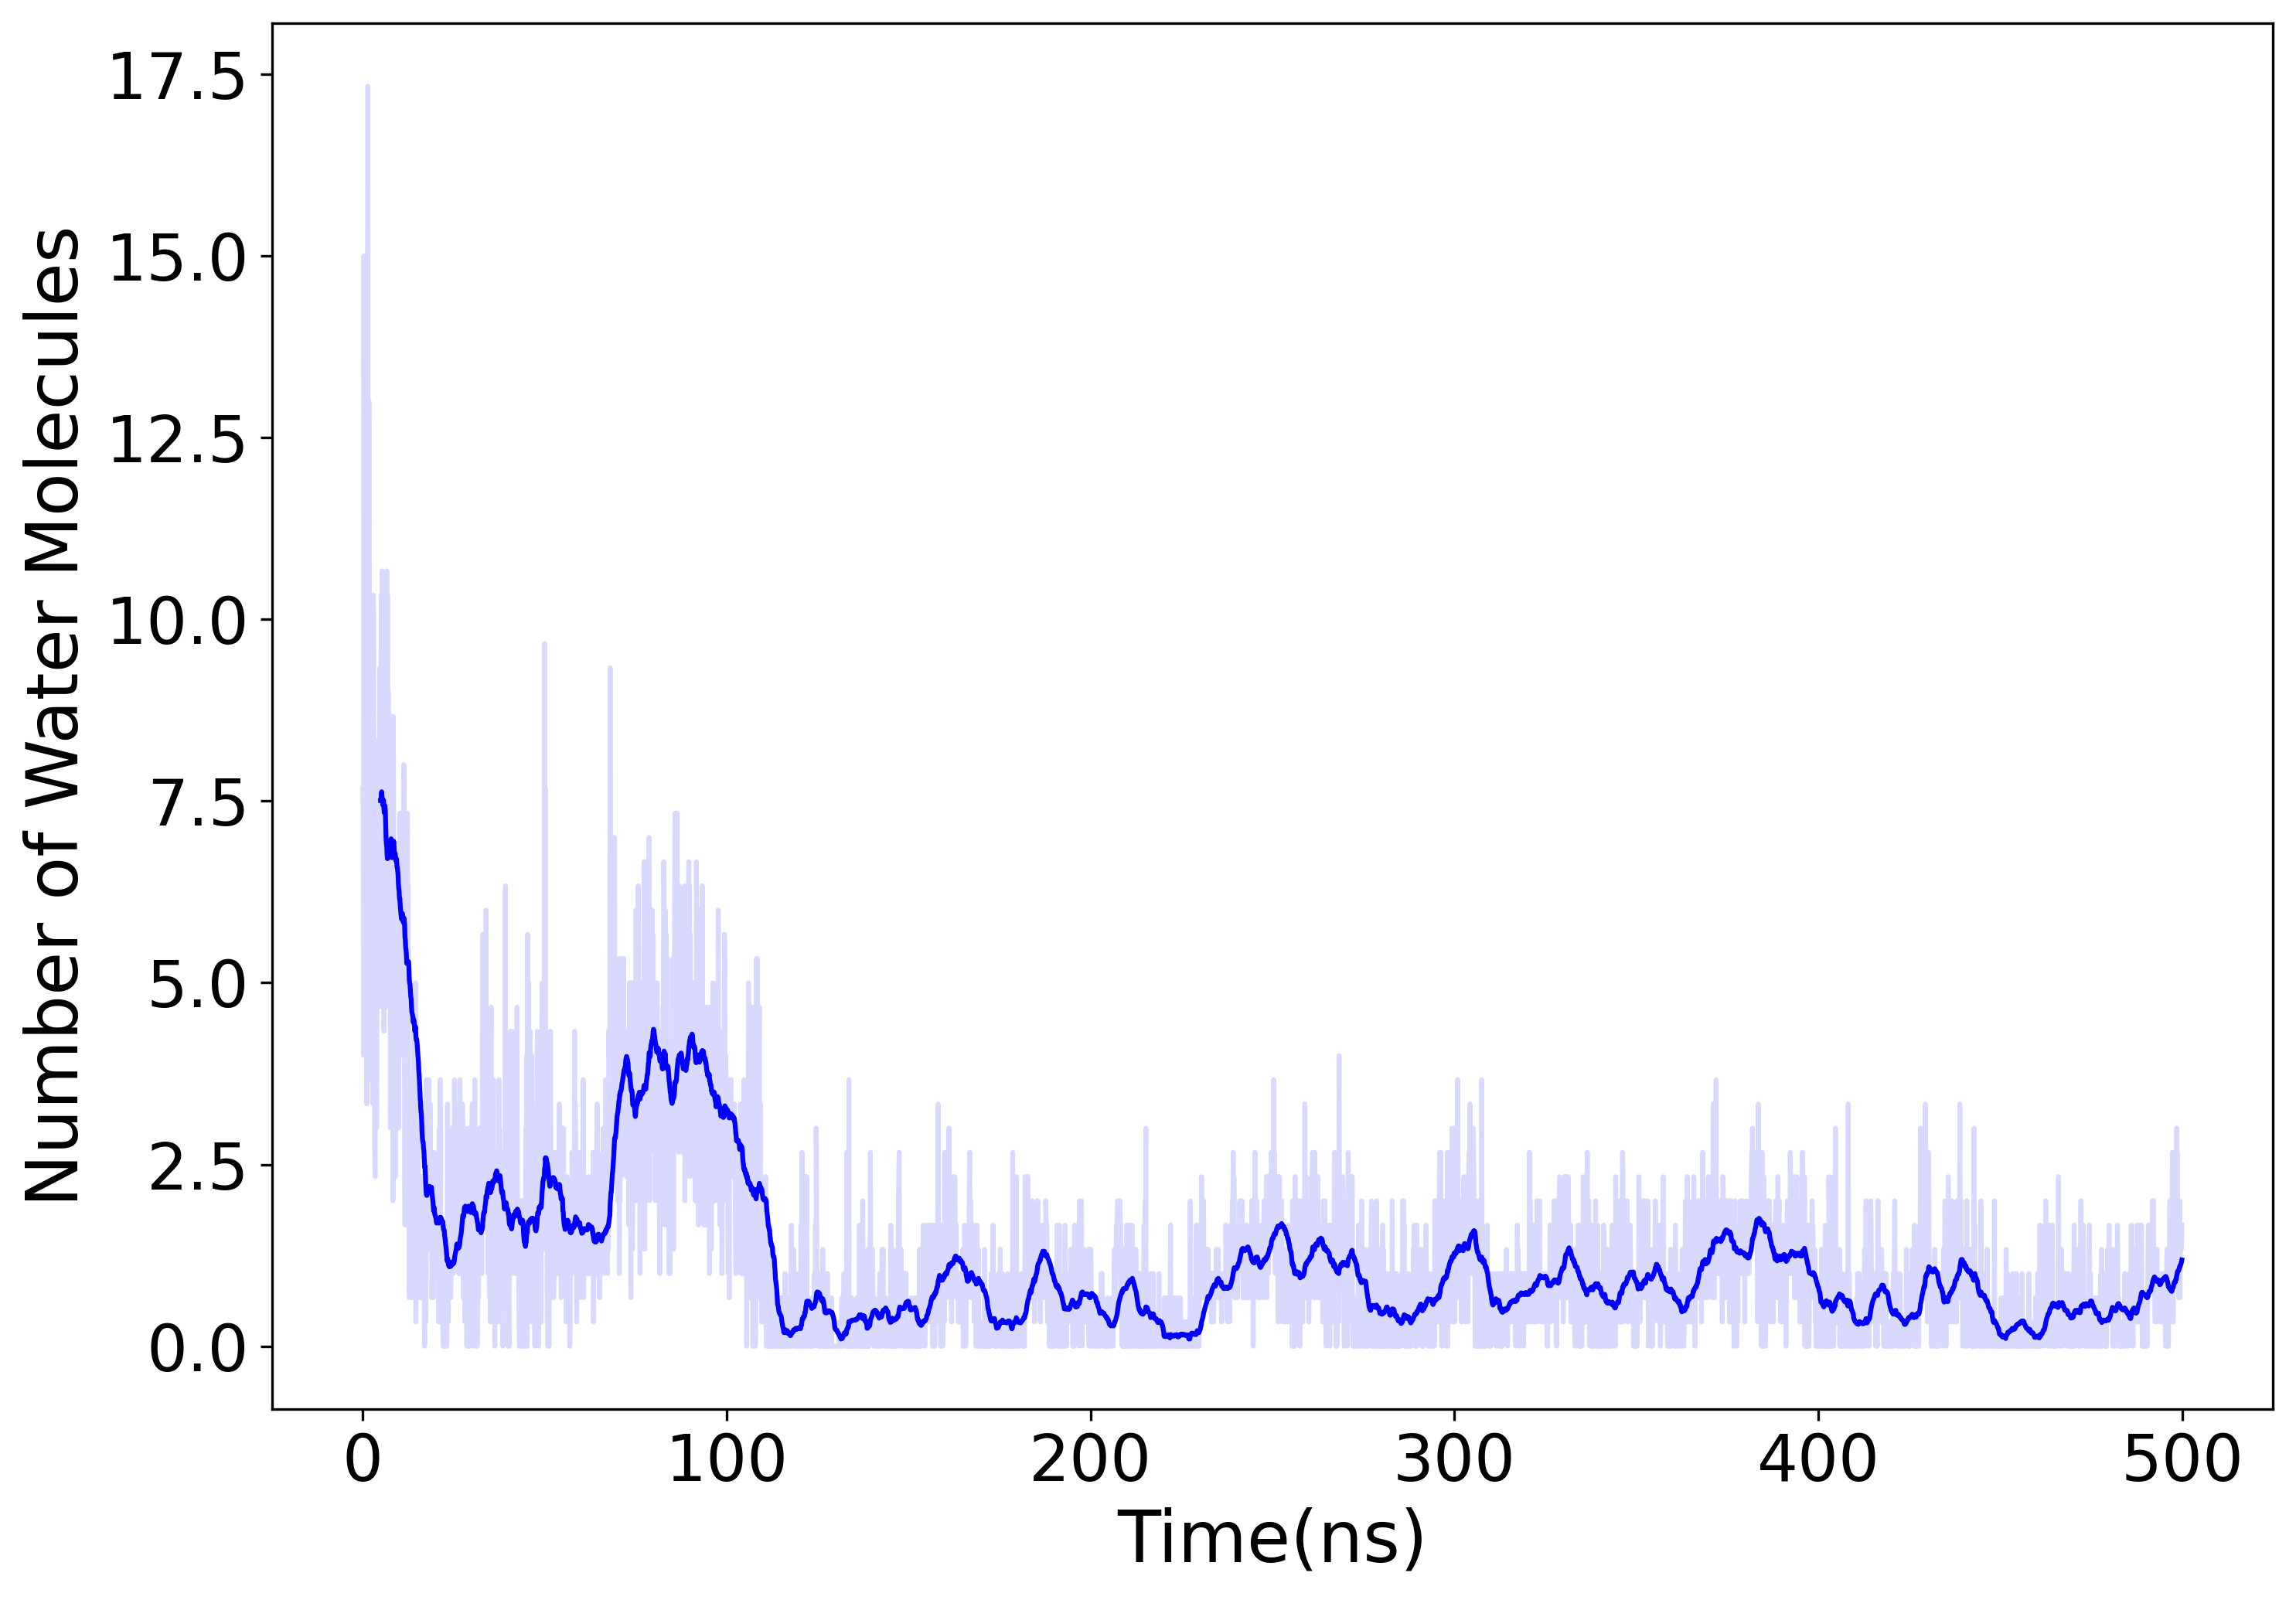

In [64]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_two['Timeframe'][:5000],df_two['Water molecules'][:5000],color="blue",alpha=0.15)
rolling_avg = df_two['Water molecules'].rolling(window=50).mean()
plt.plot(df_two['Timeframe'][:5000],rolling_avg[:5000],color="blue",label=r"without Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
#plt.legend(fontsize=20)
plt.savefig("Number of water molecules (+2-state) without Ca 500ns with 3A (rolling).png",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

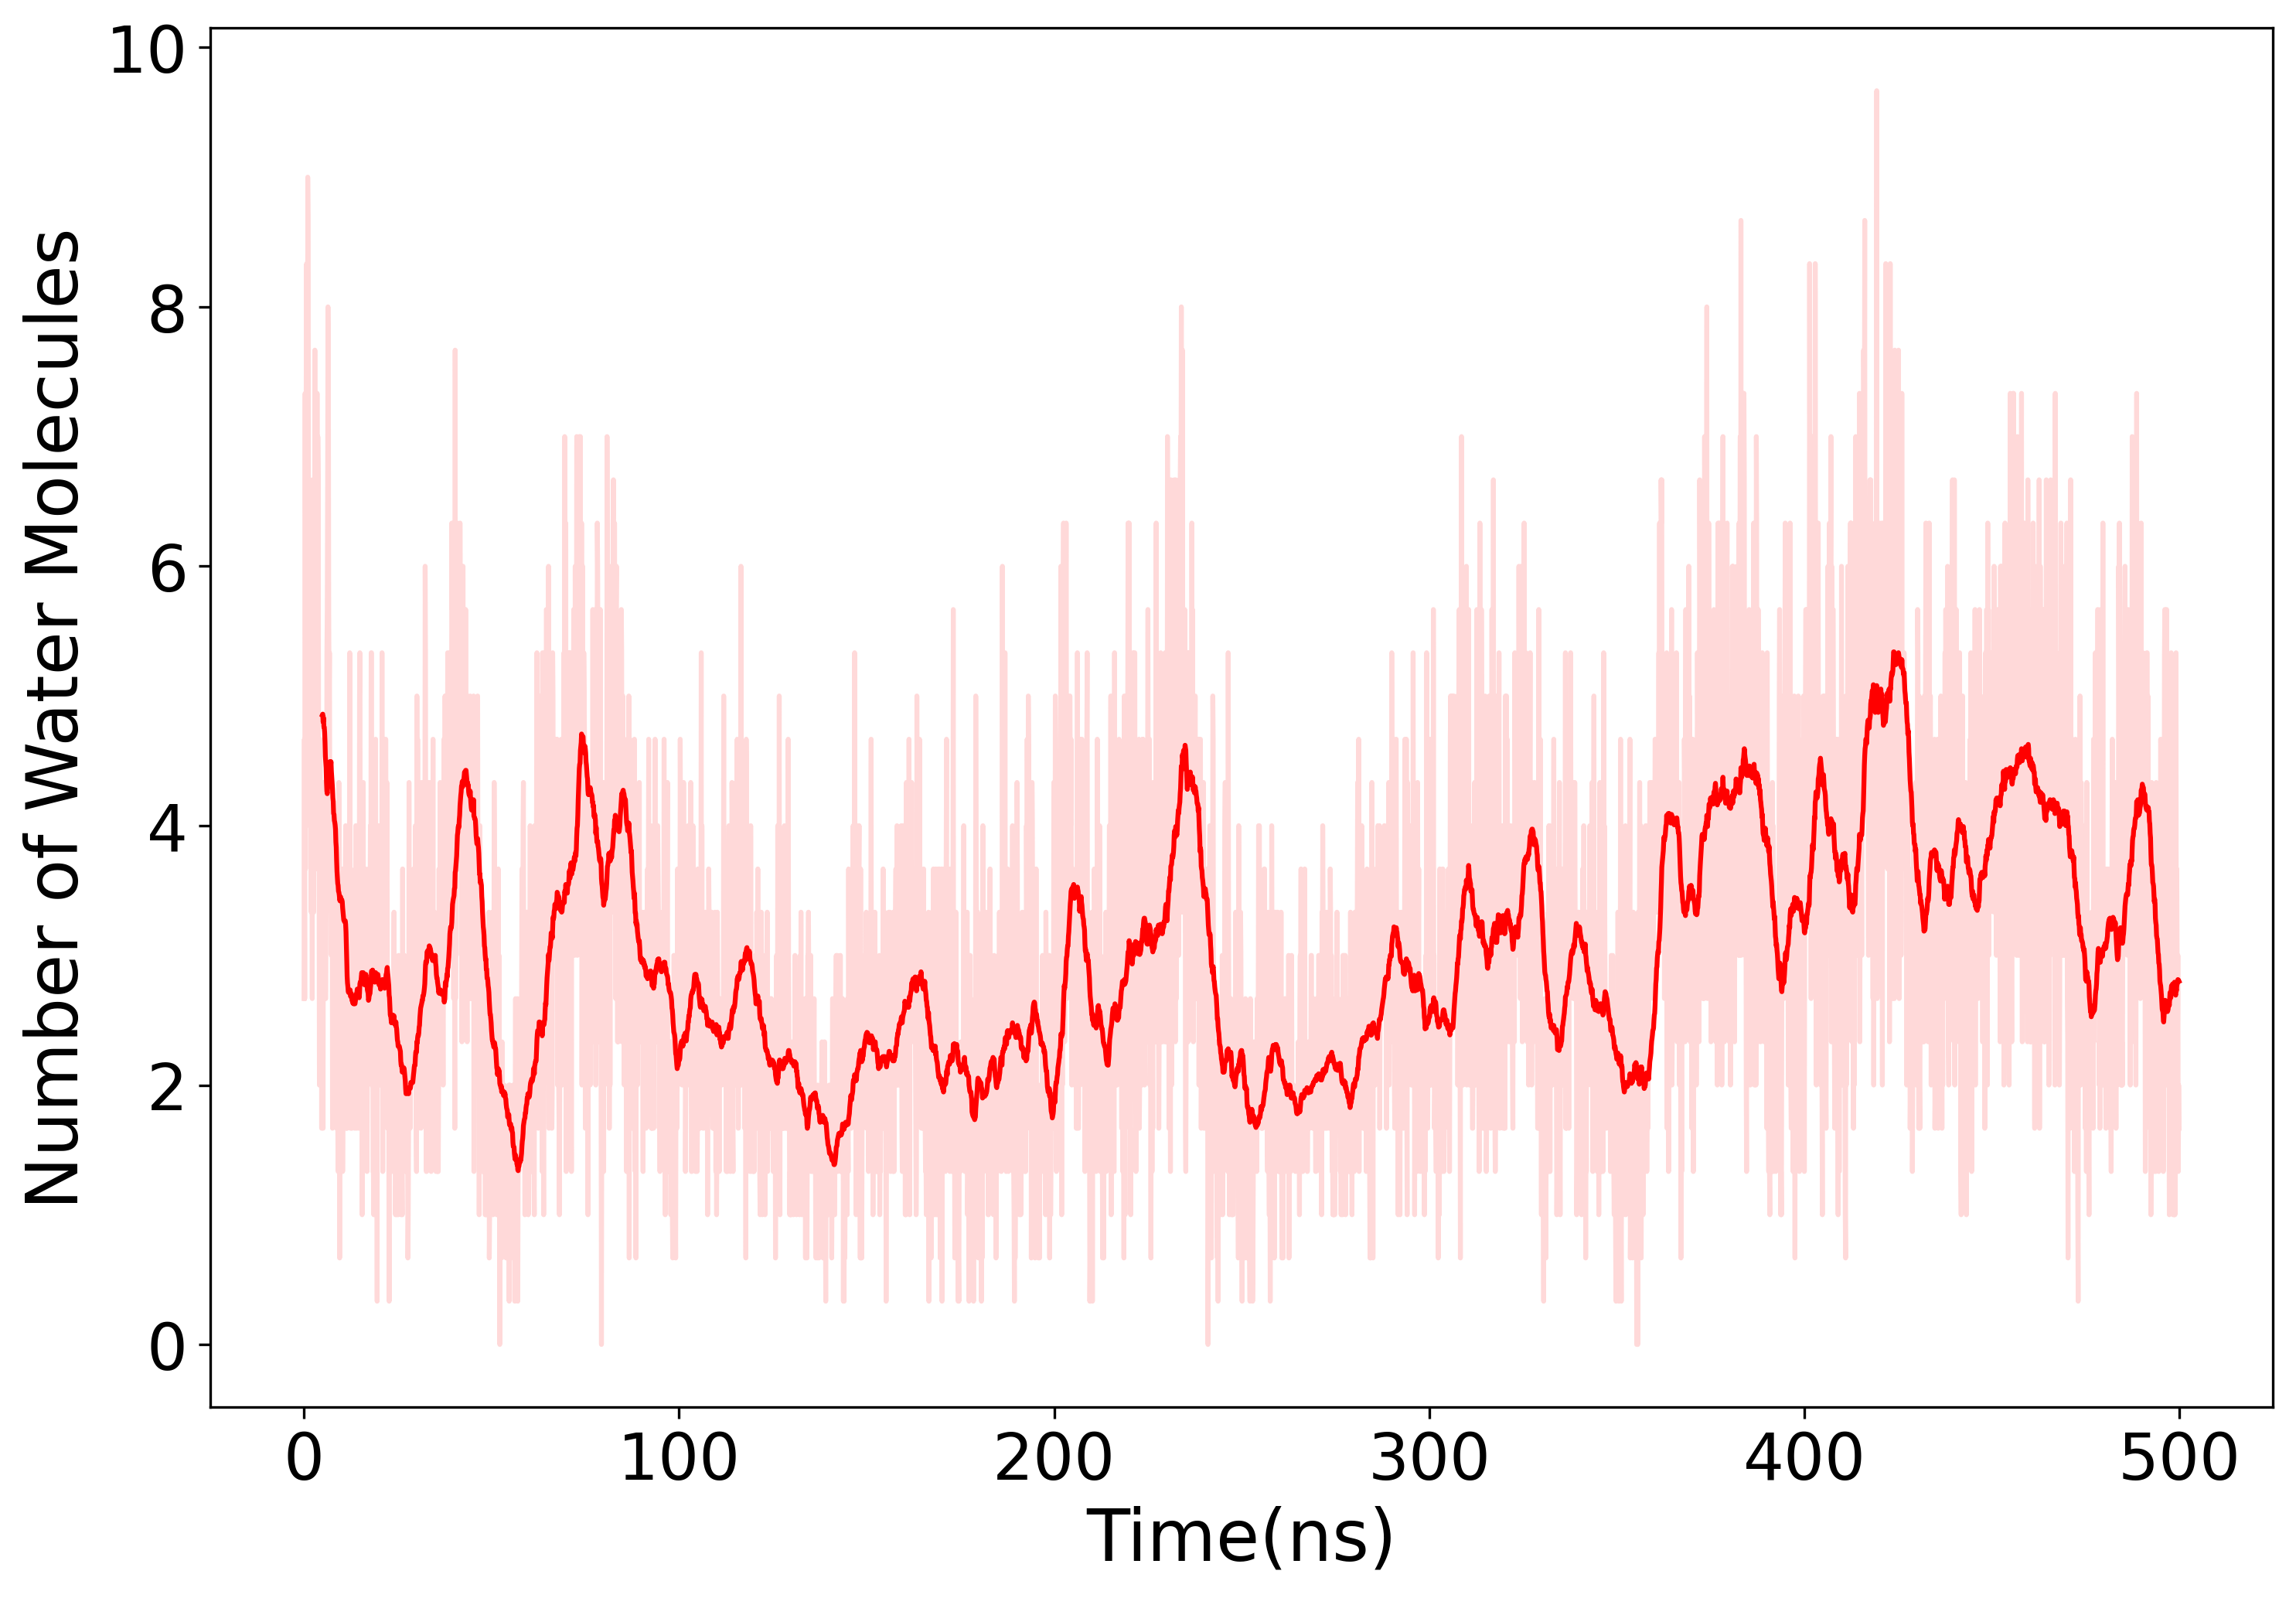

In [63]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_two_ca['Timeframe'][:5000],df_two_ca['Water molecules'][:5000],color="red",alpha=0.15)
rolling_avg = df_two_ca['Water molecules'].rolling(window=50).mean()
plt.plot(df_two_ca['Timeframe'][:5000],rolling_avg[:5000],color="red",label=r"with Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
#plt.legend(fontsize=20)
plt.savefig("Number of water molecules (+2-state) with Ca 500ns with 3A (rolling).pdf",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

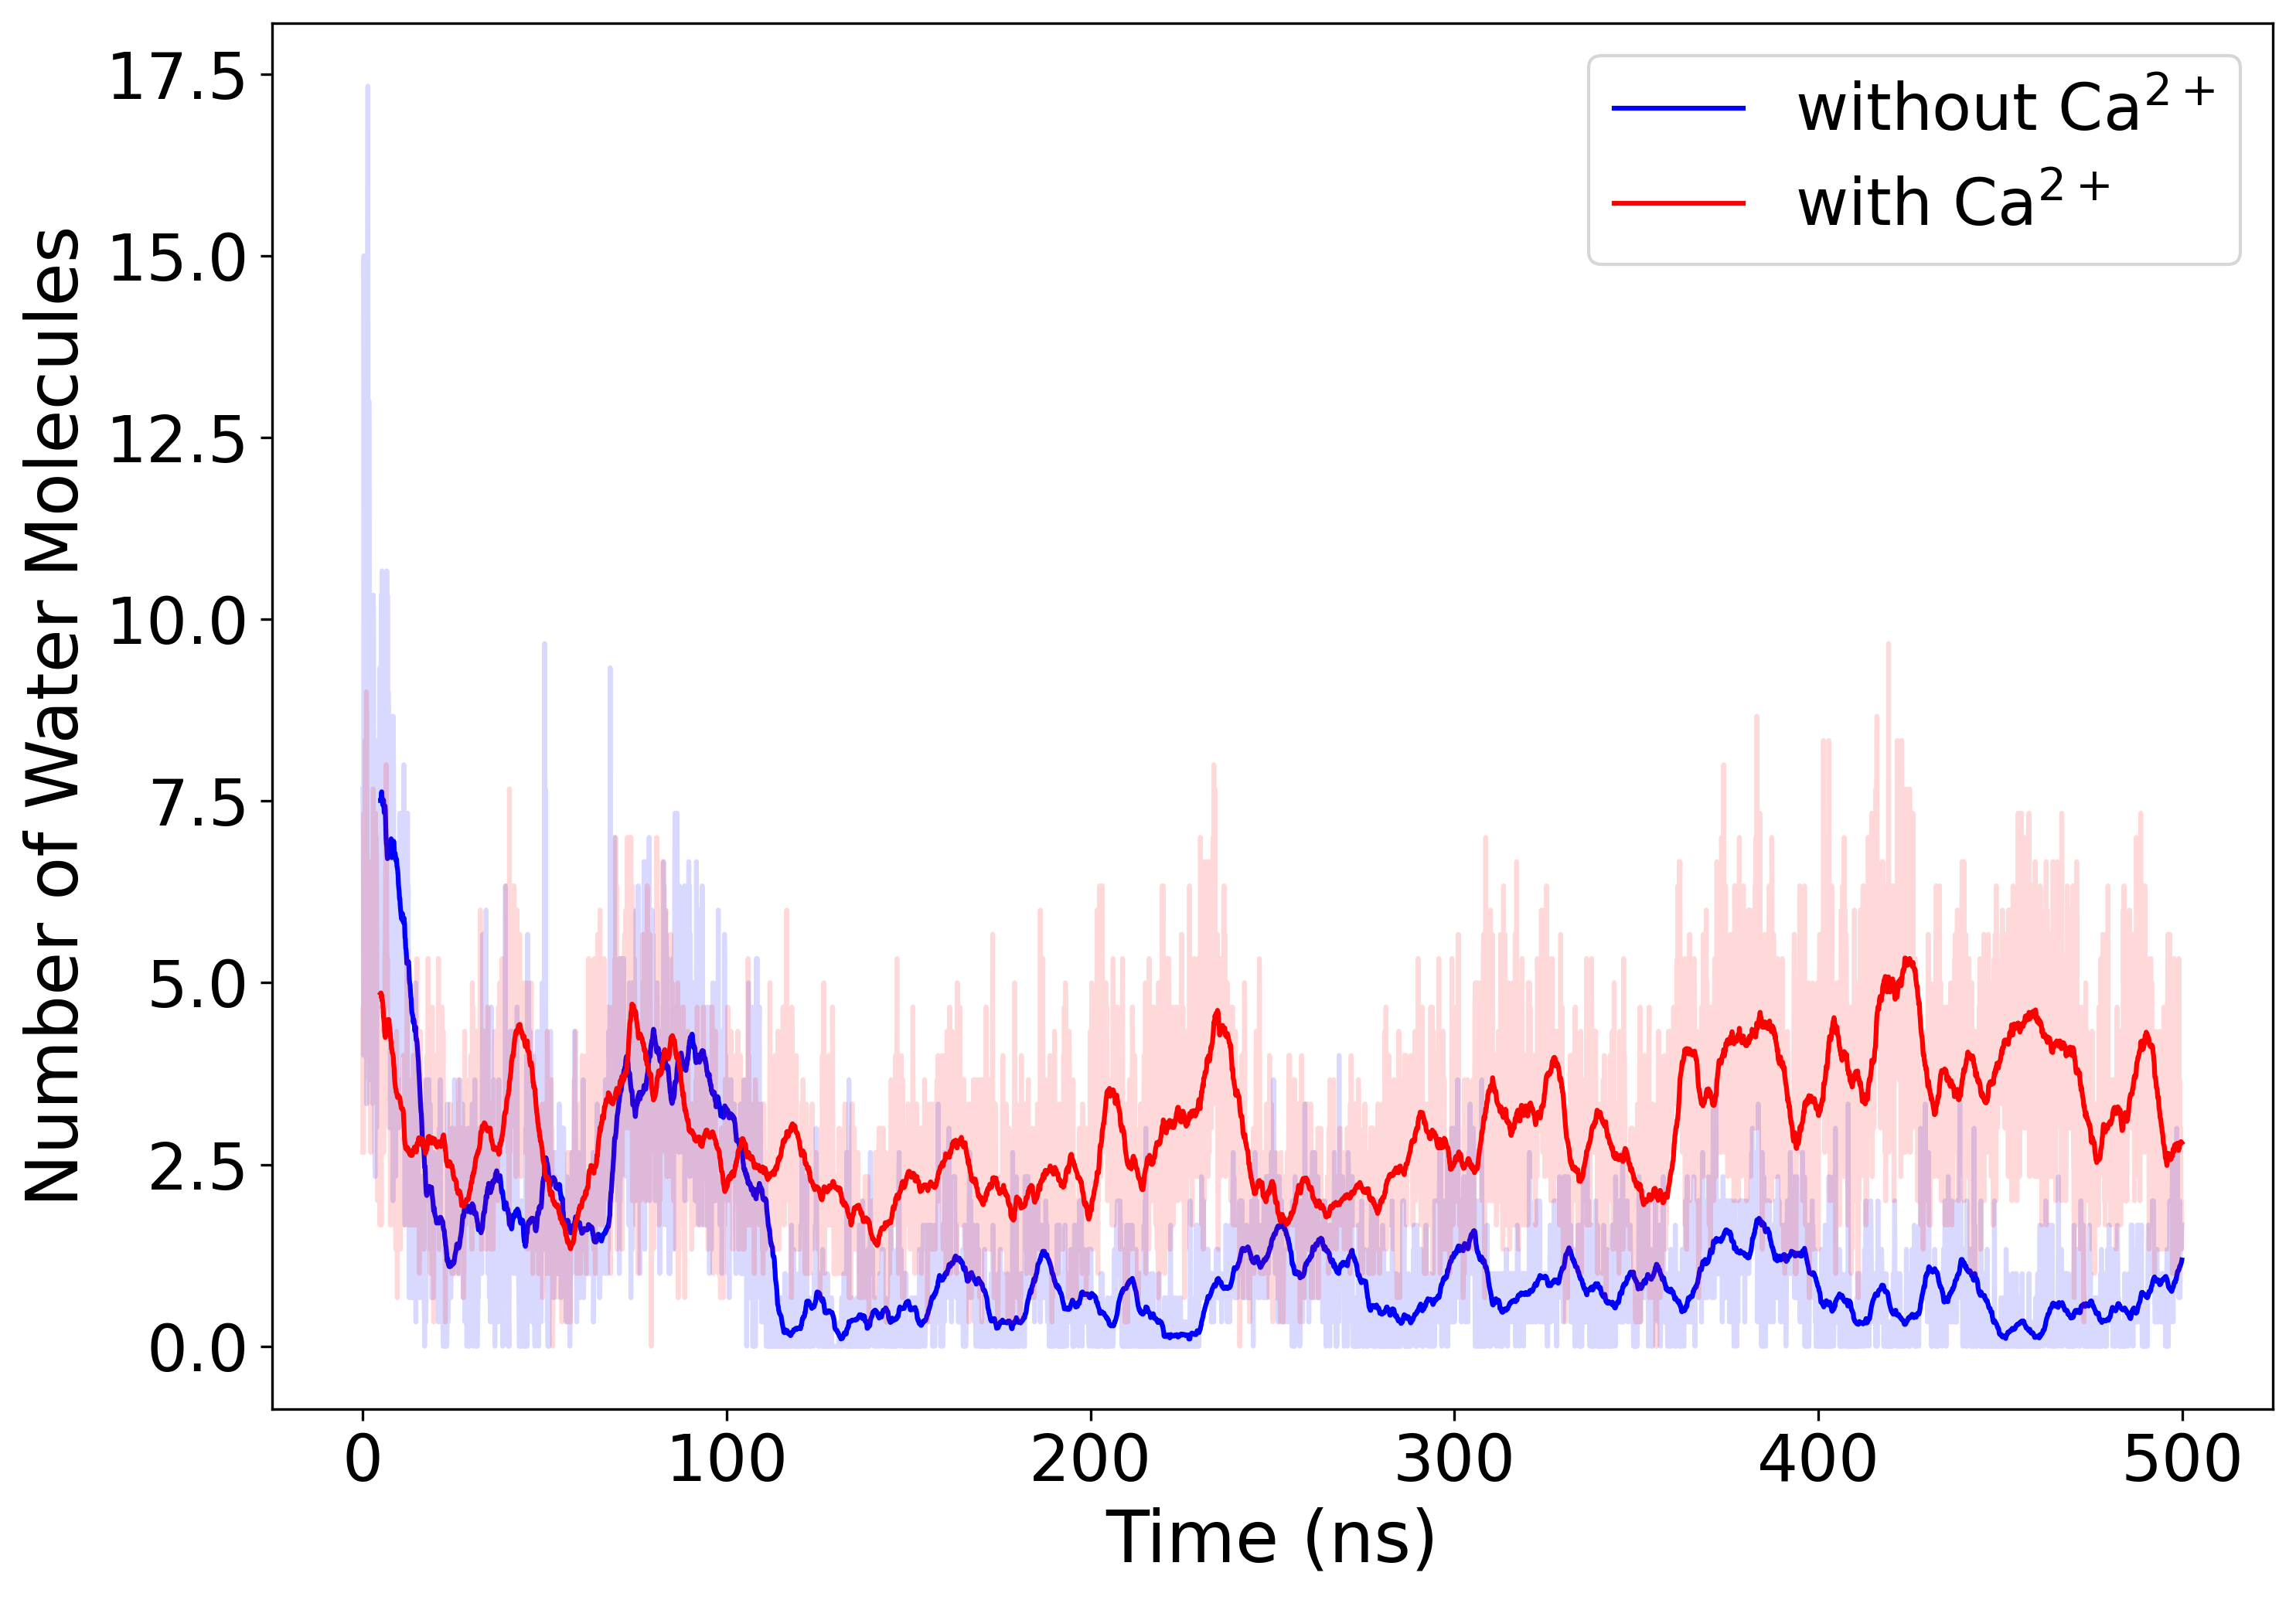

In [66]:
plot_water_molecules(df_two,df_two_ca,"Number of water molecules (+2-state) with and without Ca (rolling).png")

In [55]:
selection = "resname TIP3 and prop z<55 and prop z>27 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"
selection_ca = "resname TIP3 and prop z<70 and prop z>42 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"

df_four = calculate_water(u_four,'df_four',selection)
df_four_ca = calculate_water(u_four_ca,'df_four_ca',selection_ca)

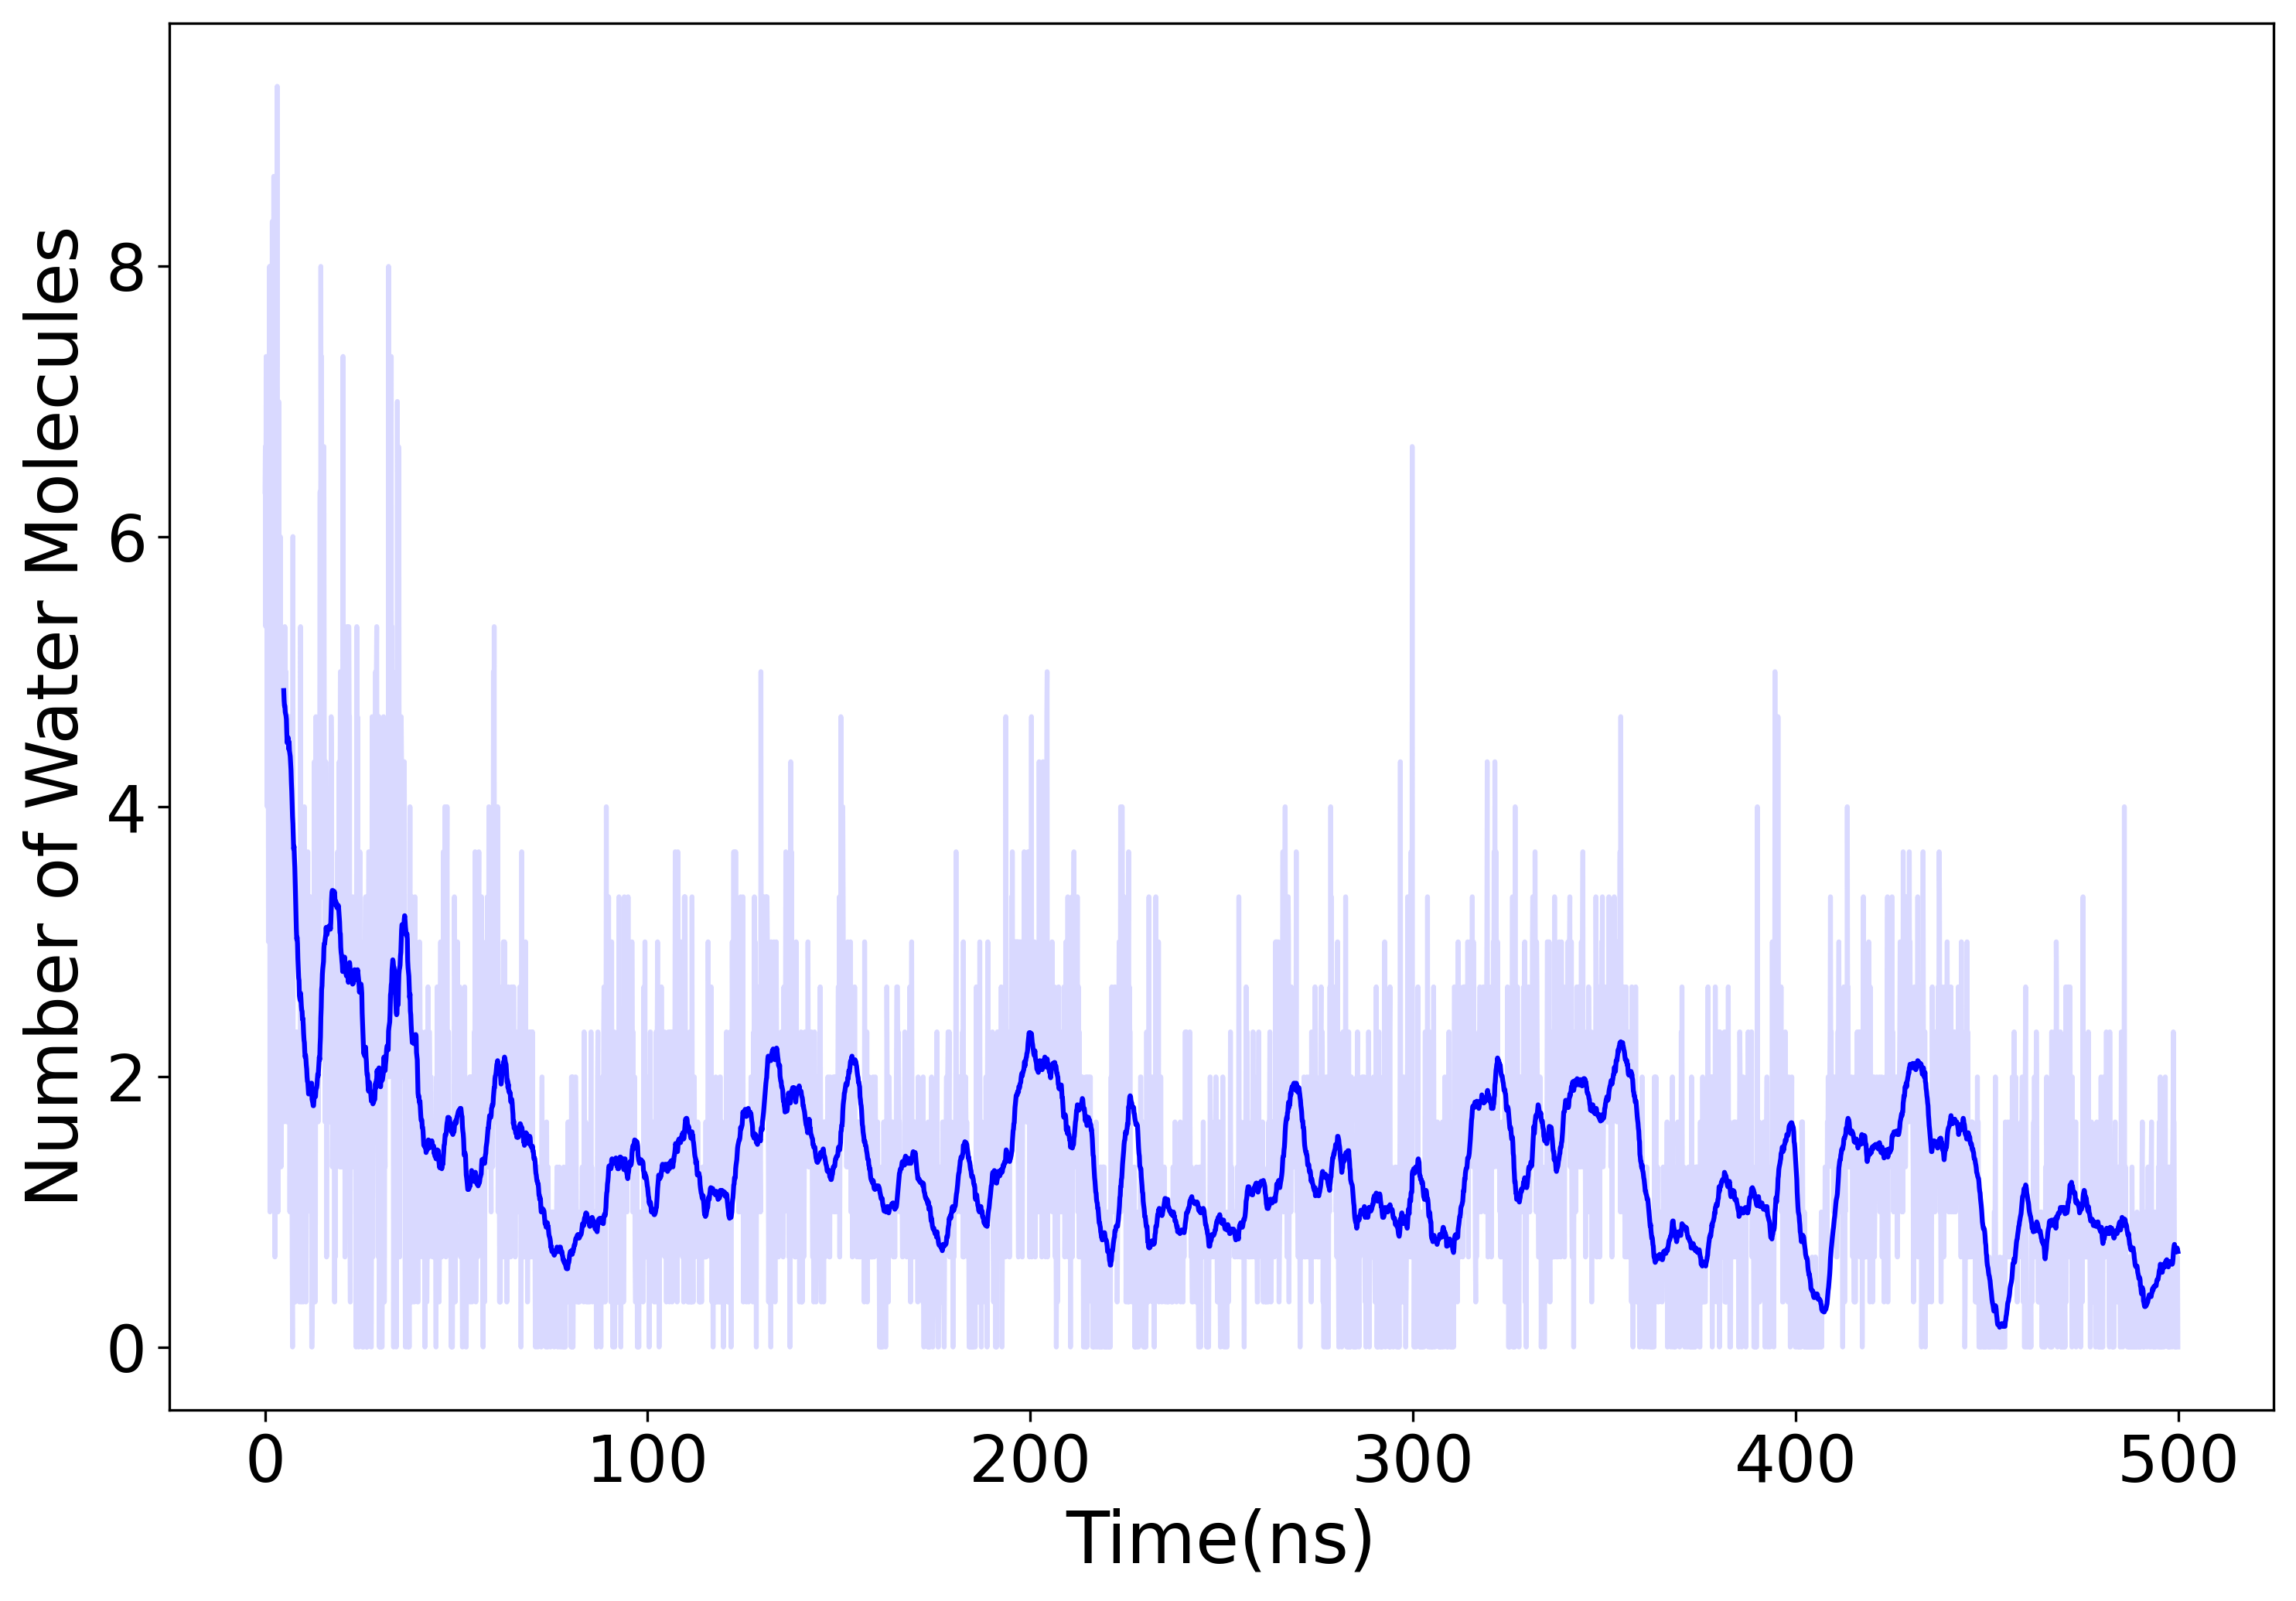

In [70]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_four['Timeframe'][:5000],df_four['Water molecules'][:5000],color="blue",alpha=0.15)
rolling_avg = df_four['Water molecules'].rolling(window=50).mean()
plt.plot(df_four['Timeframe'][:5000],rolling_avg[:5000],color="blue",label=r"without Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Number of water molecules (+4-state) without Ca 500ns with 3A (rolling).png",dpi=300)
plt.show()

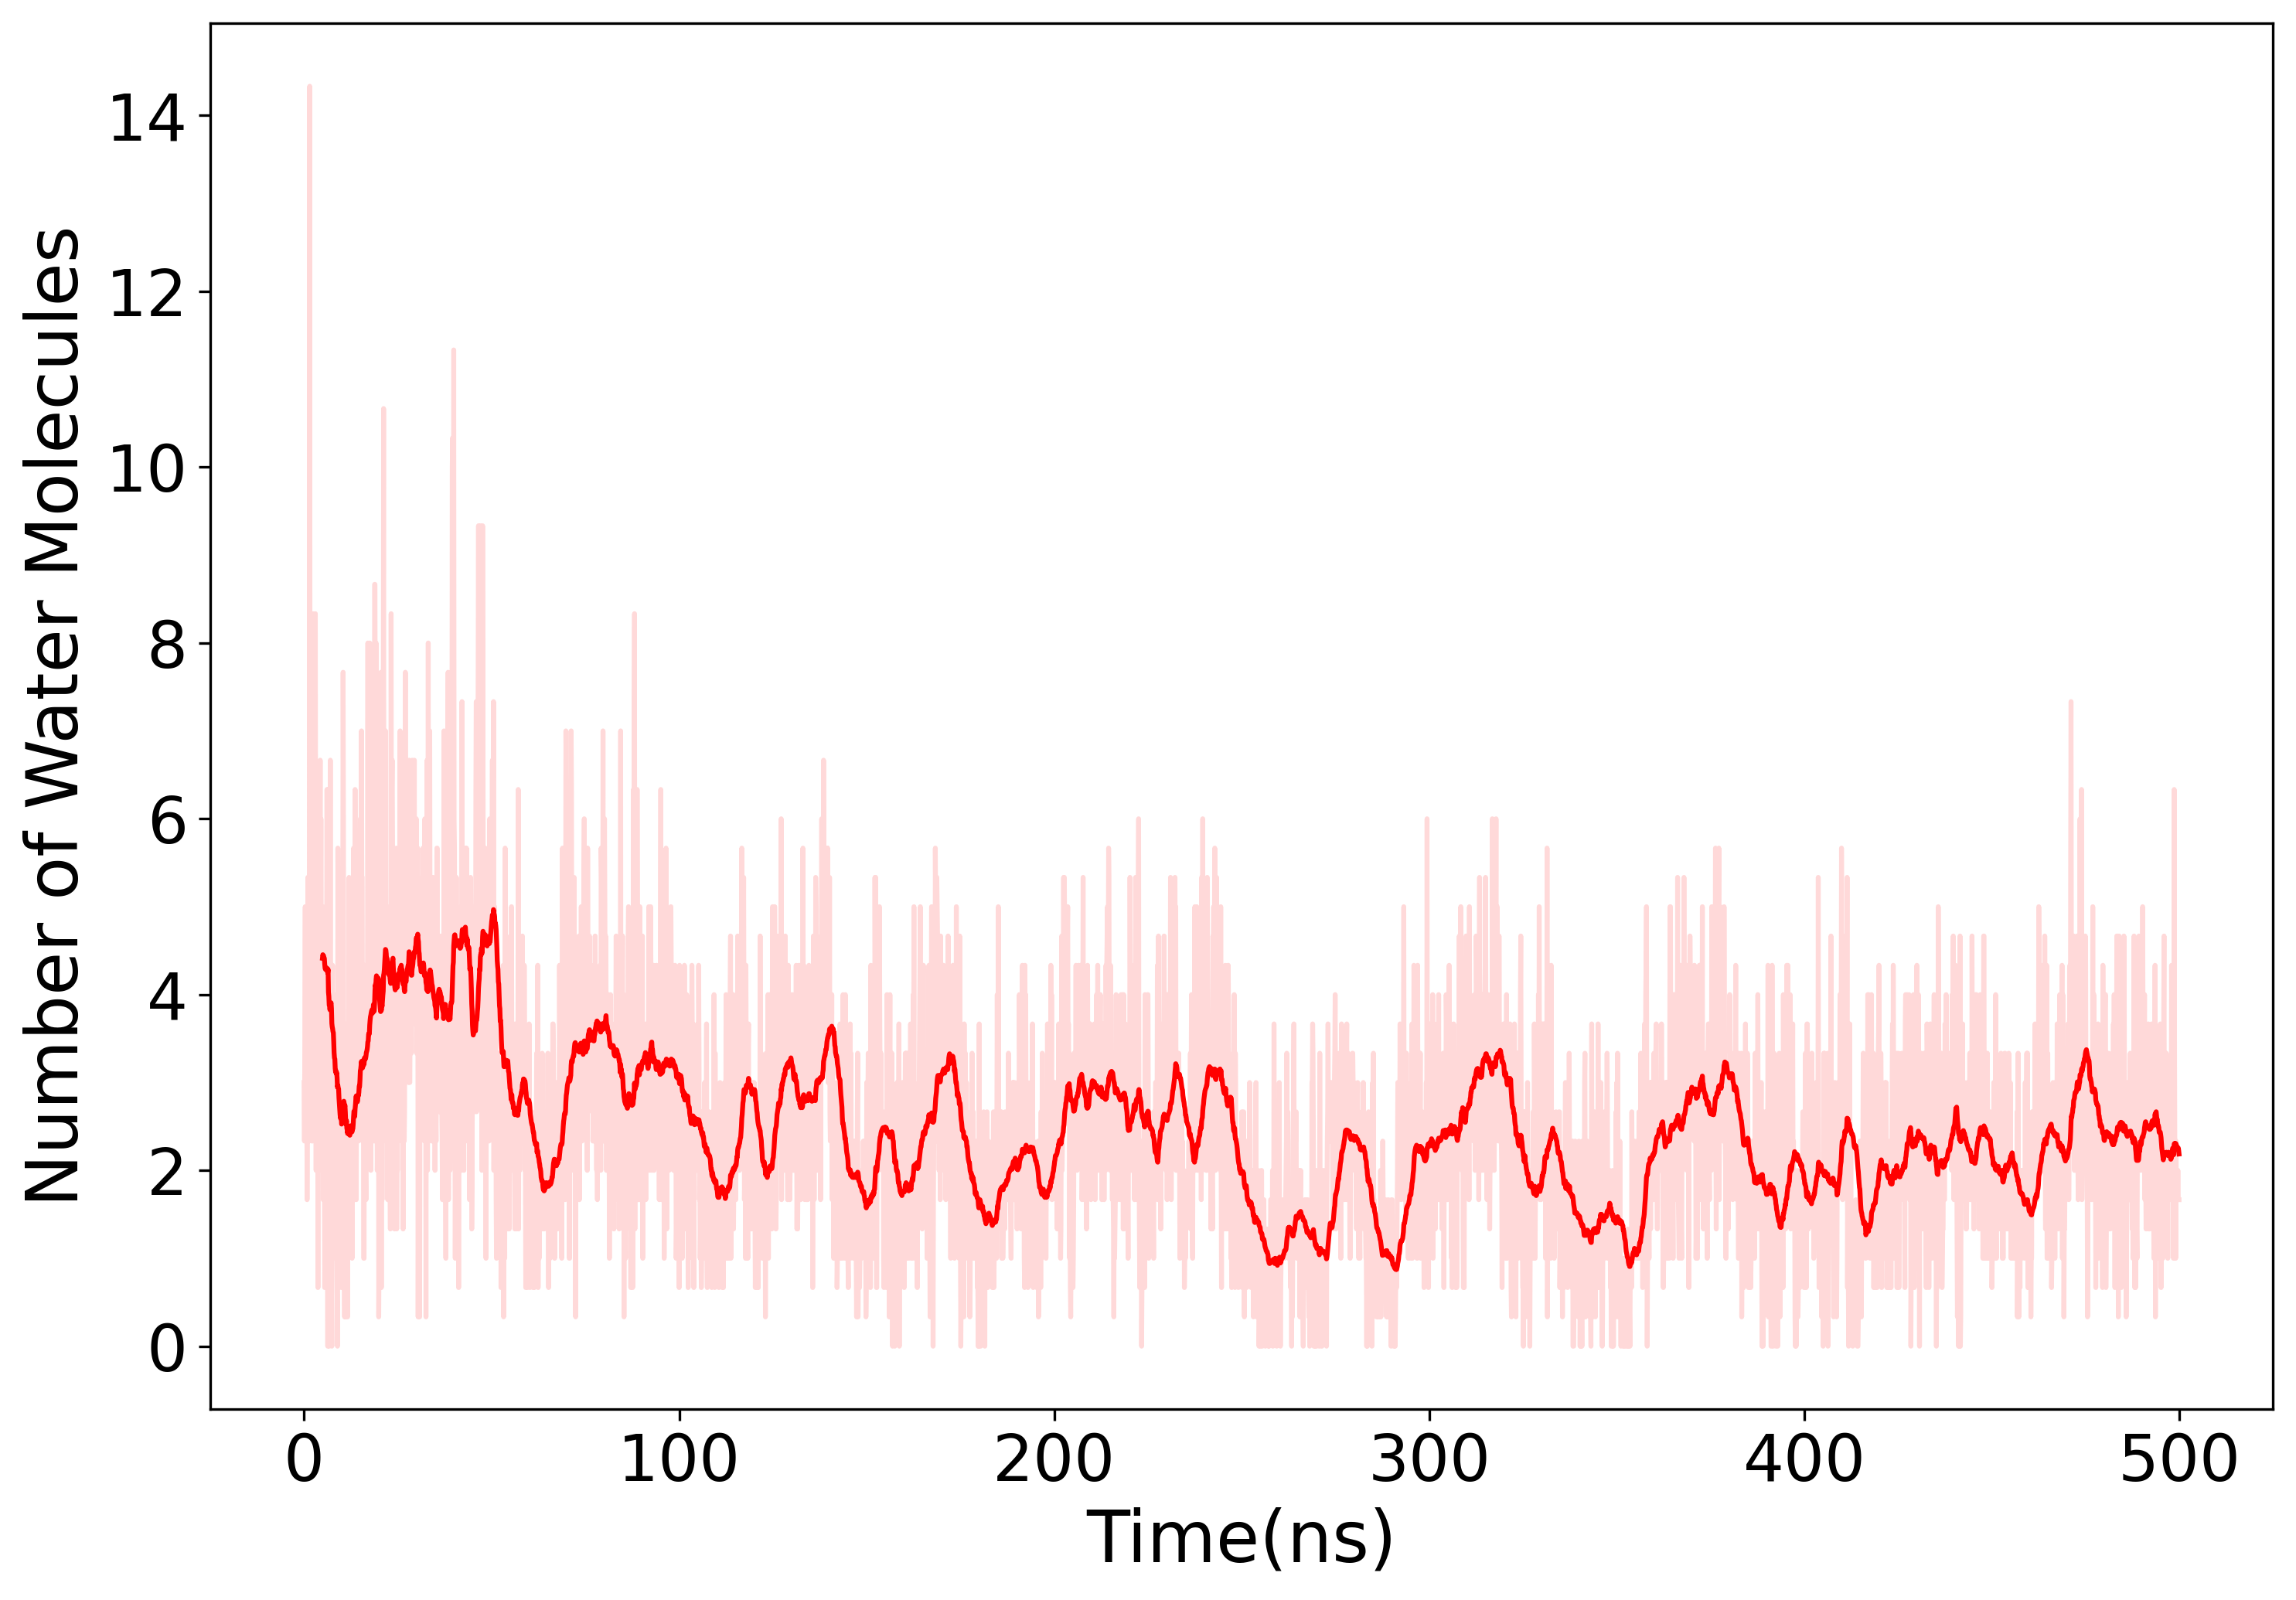

In [69]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_four_ca['Timeframe'][:5000],df_four_ca['Water molecules'][:5000],color="red",alpha=0.15)
rolling_avg = df_four_ca['Water molecules'].rolling(window=50).mean()
plt.plot(df_four_ca['Timeframe'][:5000],rolling_avg[:5000],color="red",label=r"with Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Number of water molecules (+4-state) with Ca 500ns with 3A (rolling).png",dpi=300)
plt.show()

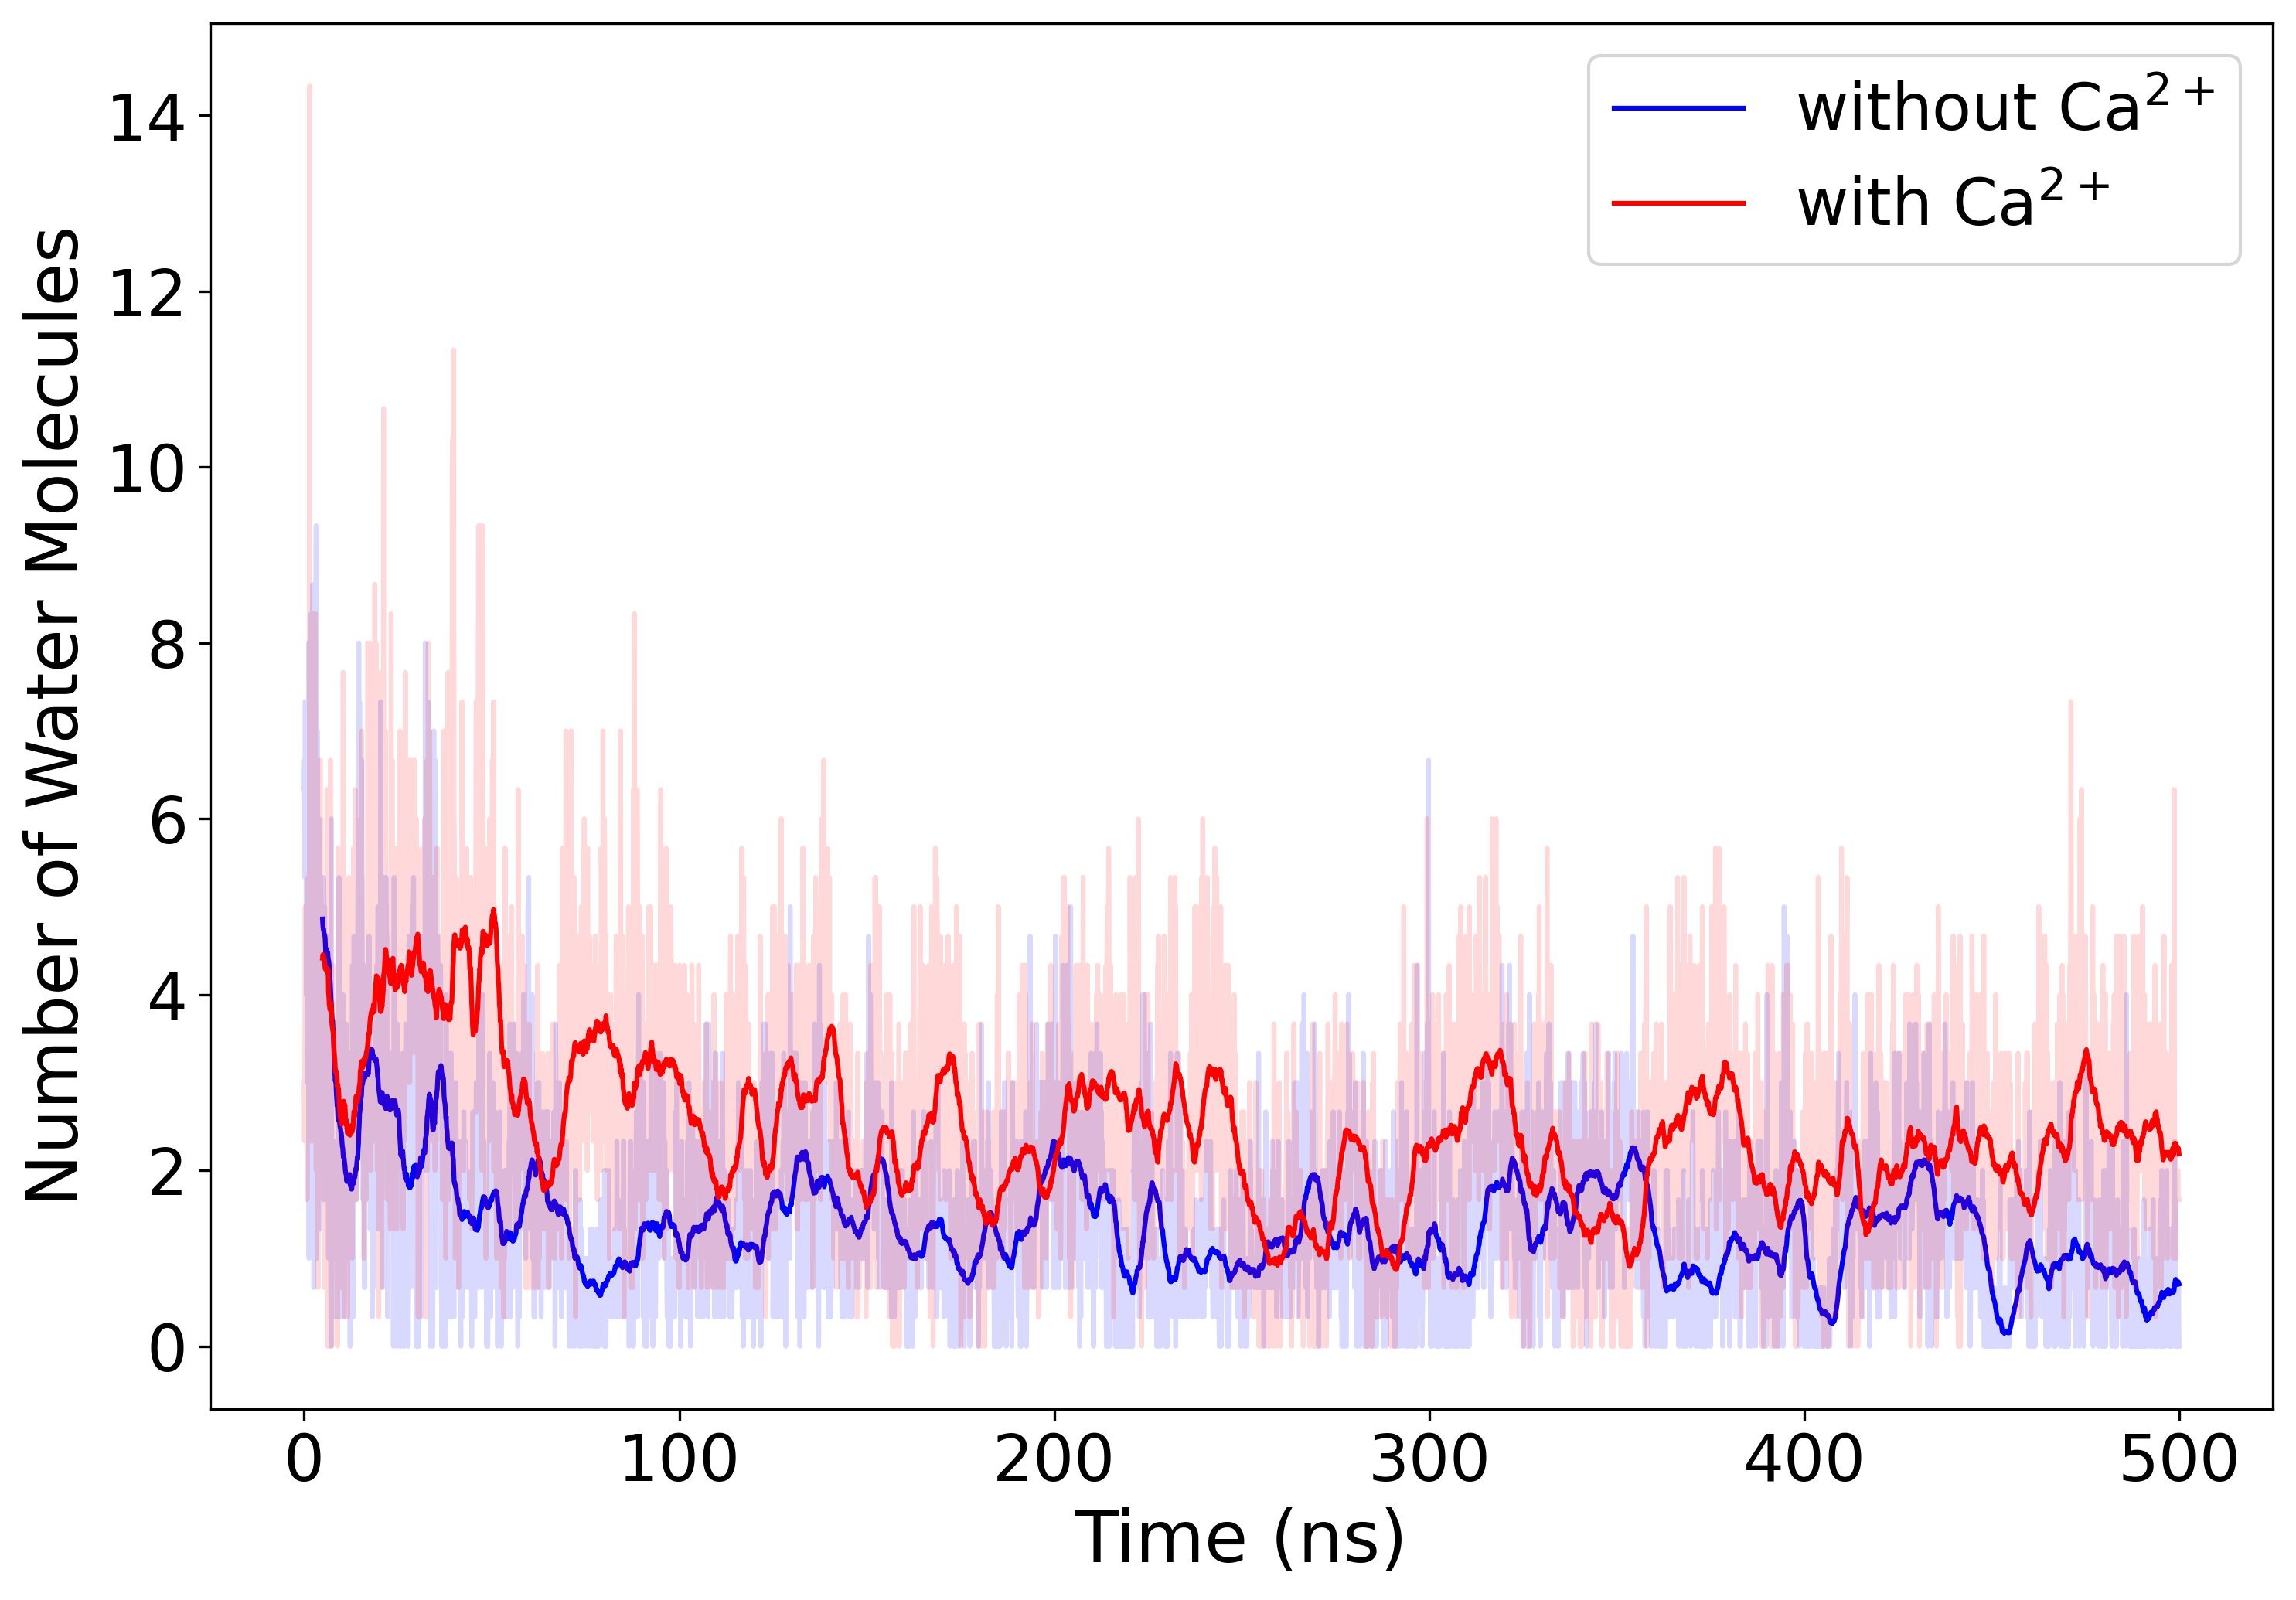

In [72]:
plot_water_molecules(df_four,df_four_ca,"Number of water molecules (+4-state) with and without Ca (rolling).png")

In [31]:
selection = "resname TIP3 and prop z<80 and prop z>52 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"
selection_ca = "resname TIP3 and prop z<75 and prop z>47 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"

df_five = calculate_water(u_five,'df_five',selection)
df_five_ca = calculate_water(u_five_ca,'df_five_ca',selection_ca)

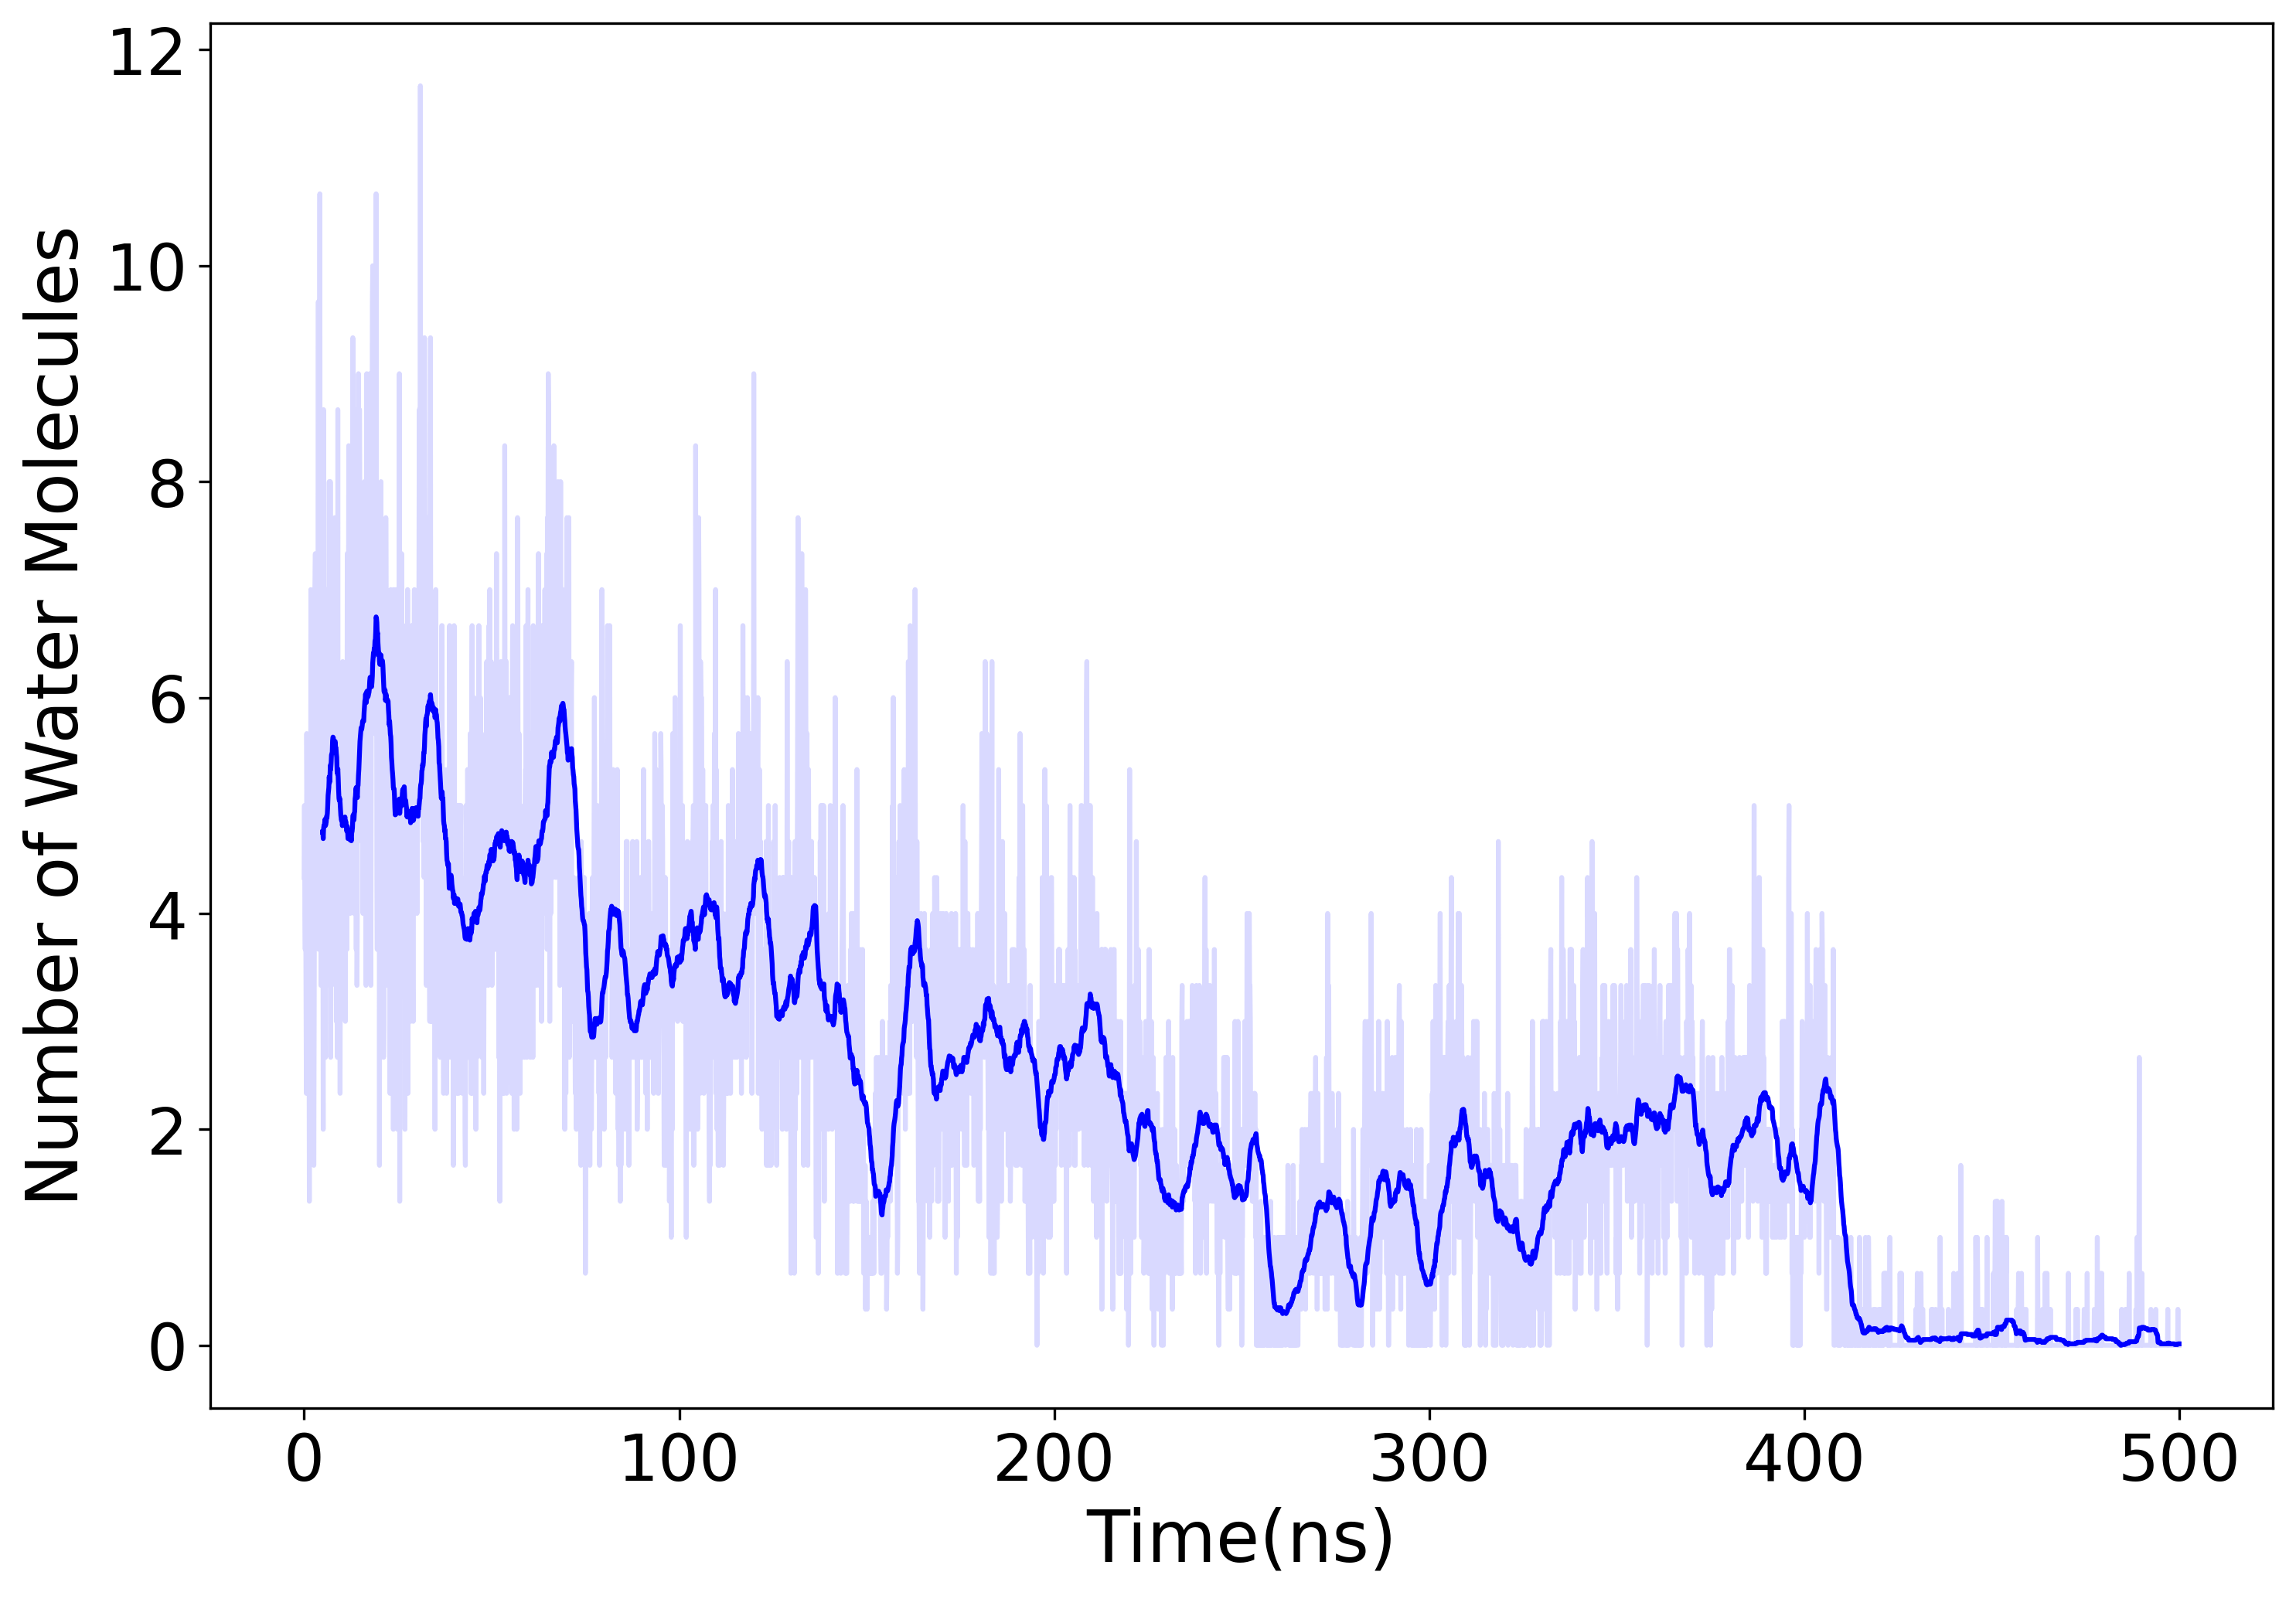

In [74]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_five['Timeframe'][:5000],df_five['Water molecules'][:5000],color="blue",alpha=0.15)
rolling_avg = df_five['Water molecules'].rolling(window=50).mean()
plt.plot(df_five['Timeframe'][:5000],rolling_avg[:5000],color="blue",label=r"without Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Number of water molecules (+5-state) without Ca 500ns with 3A (rolling).pdf",dpi=300)
plt.show()

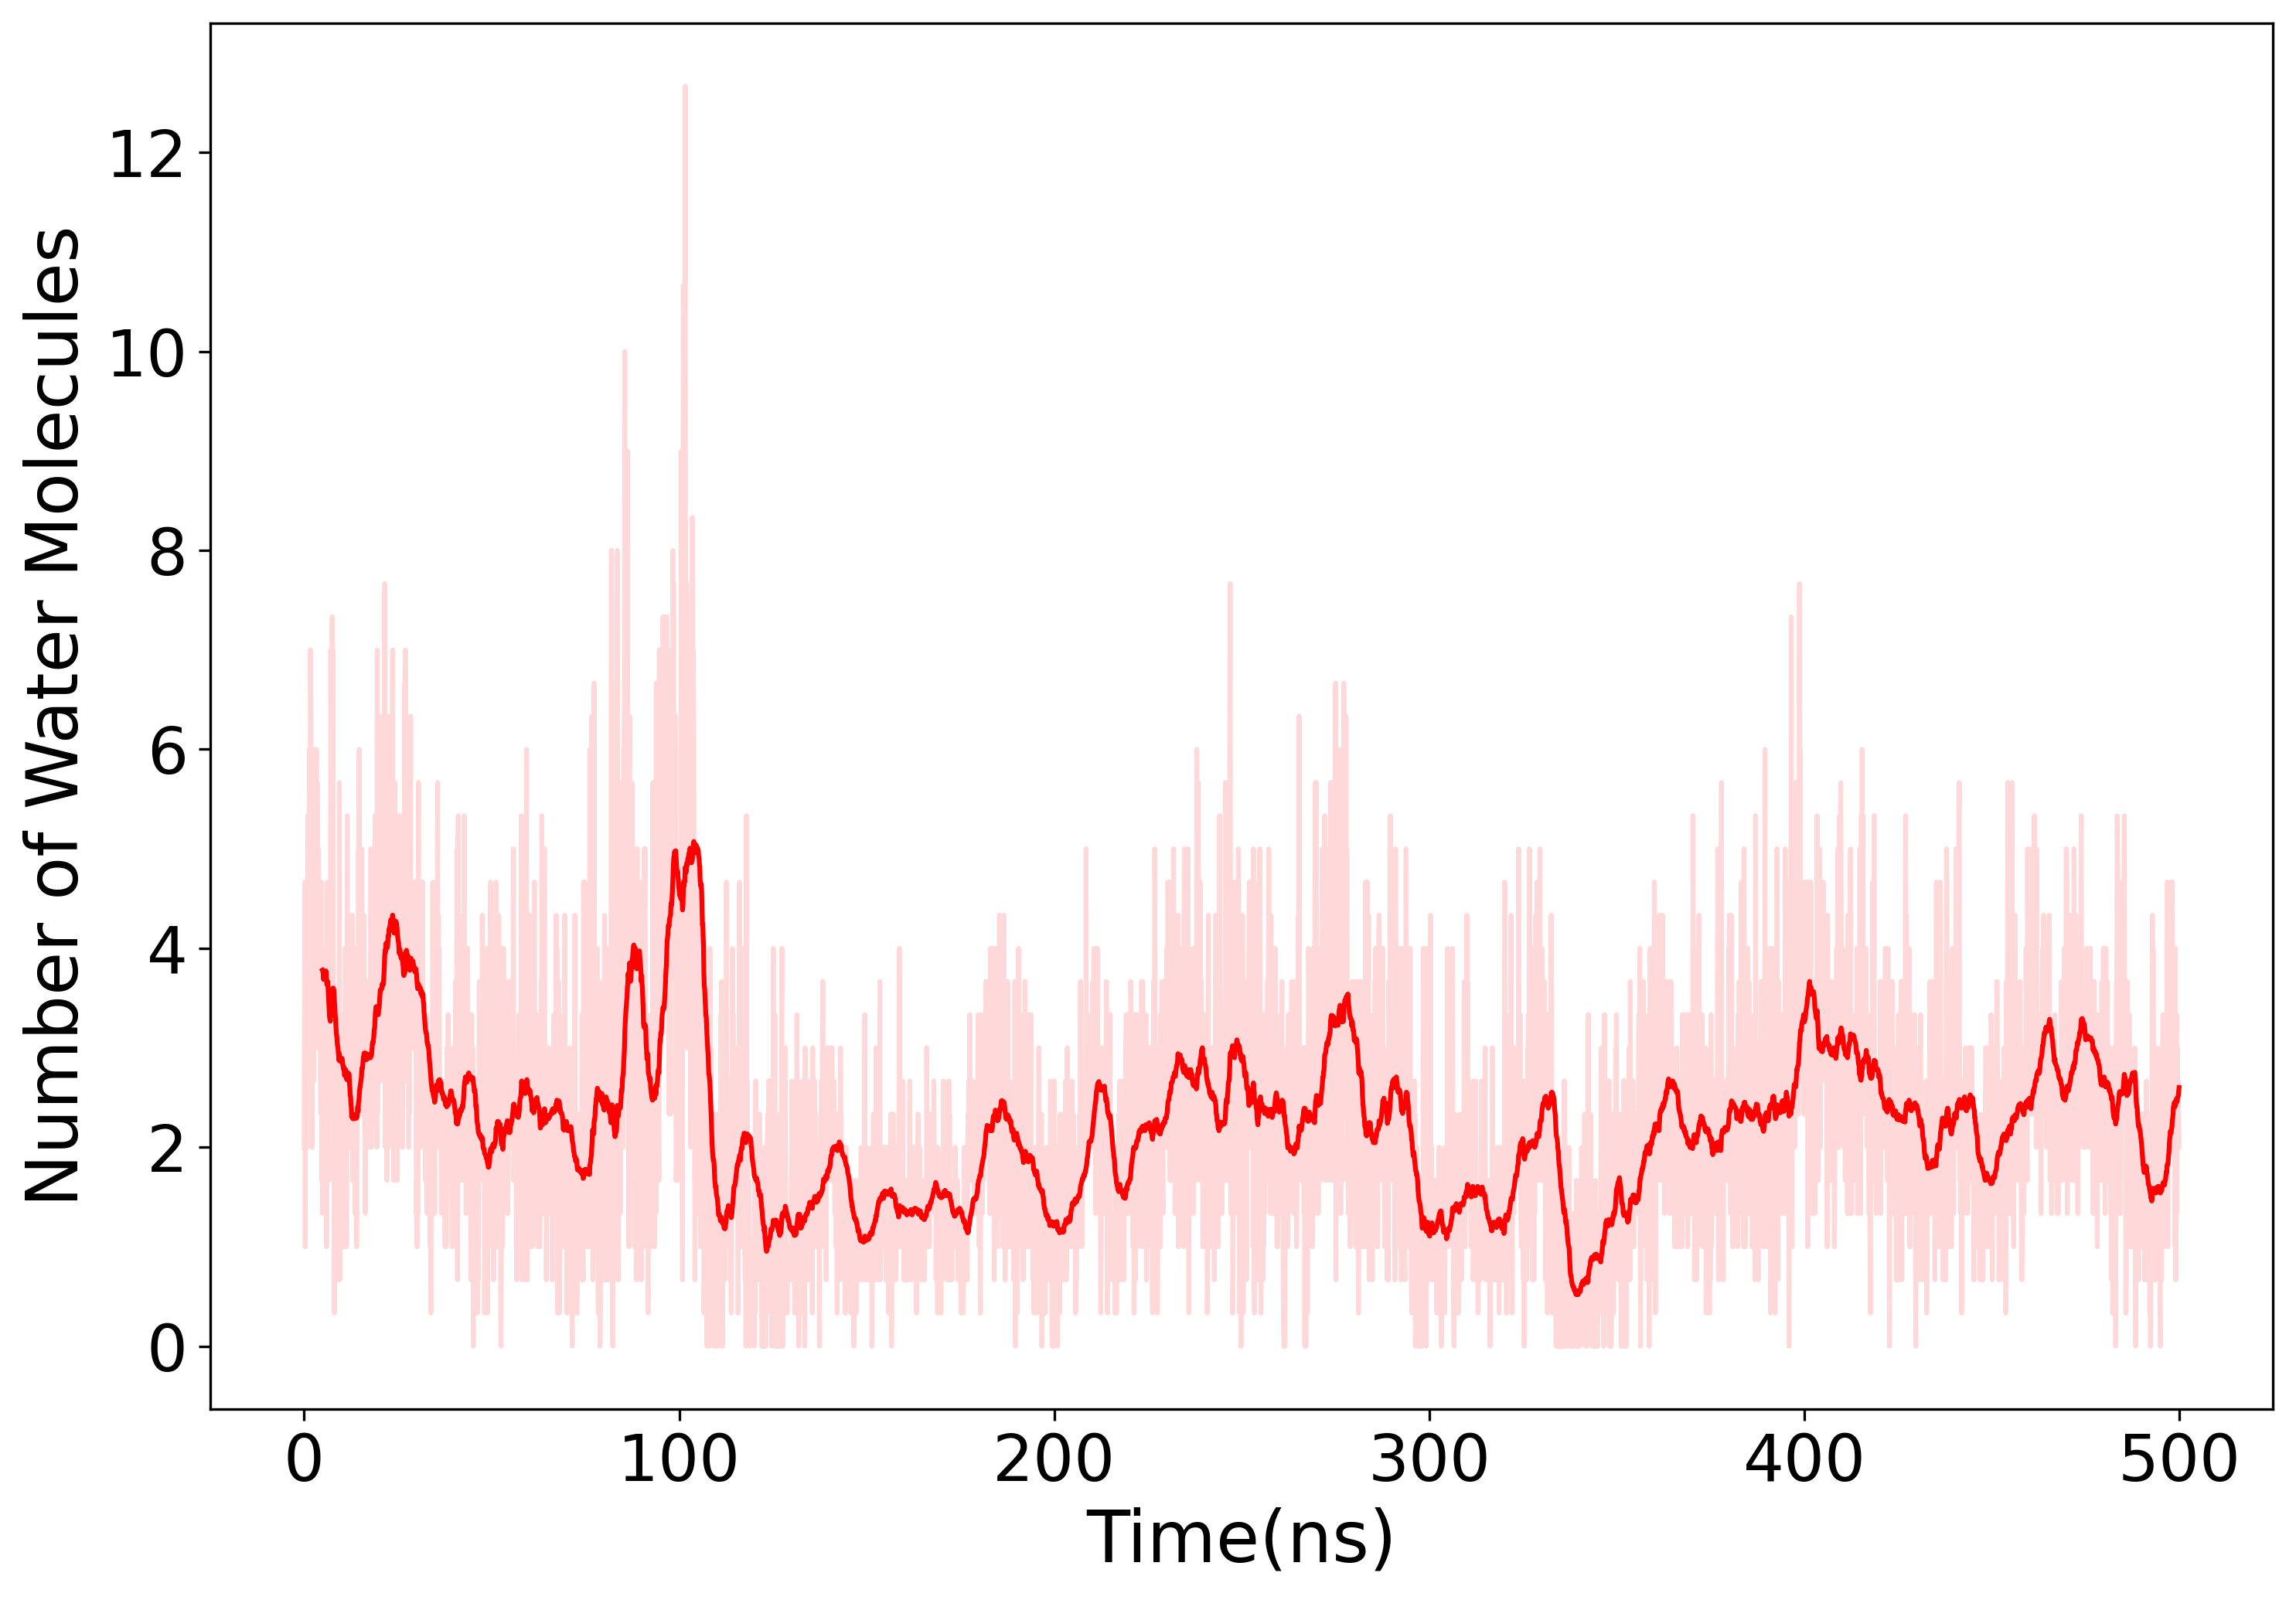

In [76]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_five_ca['Timeframe'][:5000],df_five_ca['Water molecules'][:5000],color="red",alpha=0.15)
rolling_avg = df_five_ca['Water molecules'].rolling(window=50).mean()
plt.plot(df_five_ca['Timeframe'][:5000],rolling_avg[:5000],color="red",label=r"with Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Number of water molecules (+5-state) with Ca 500ns with 3A (rolling).pdf",dpi=300)
plt.show()

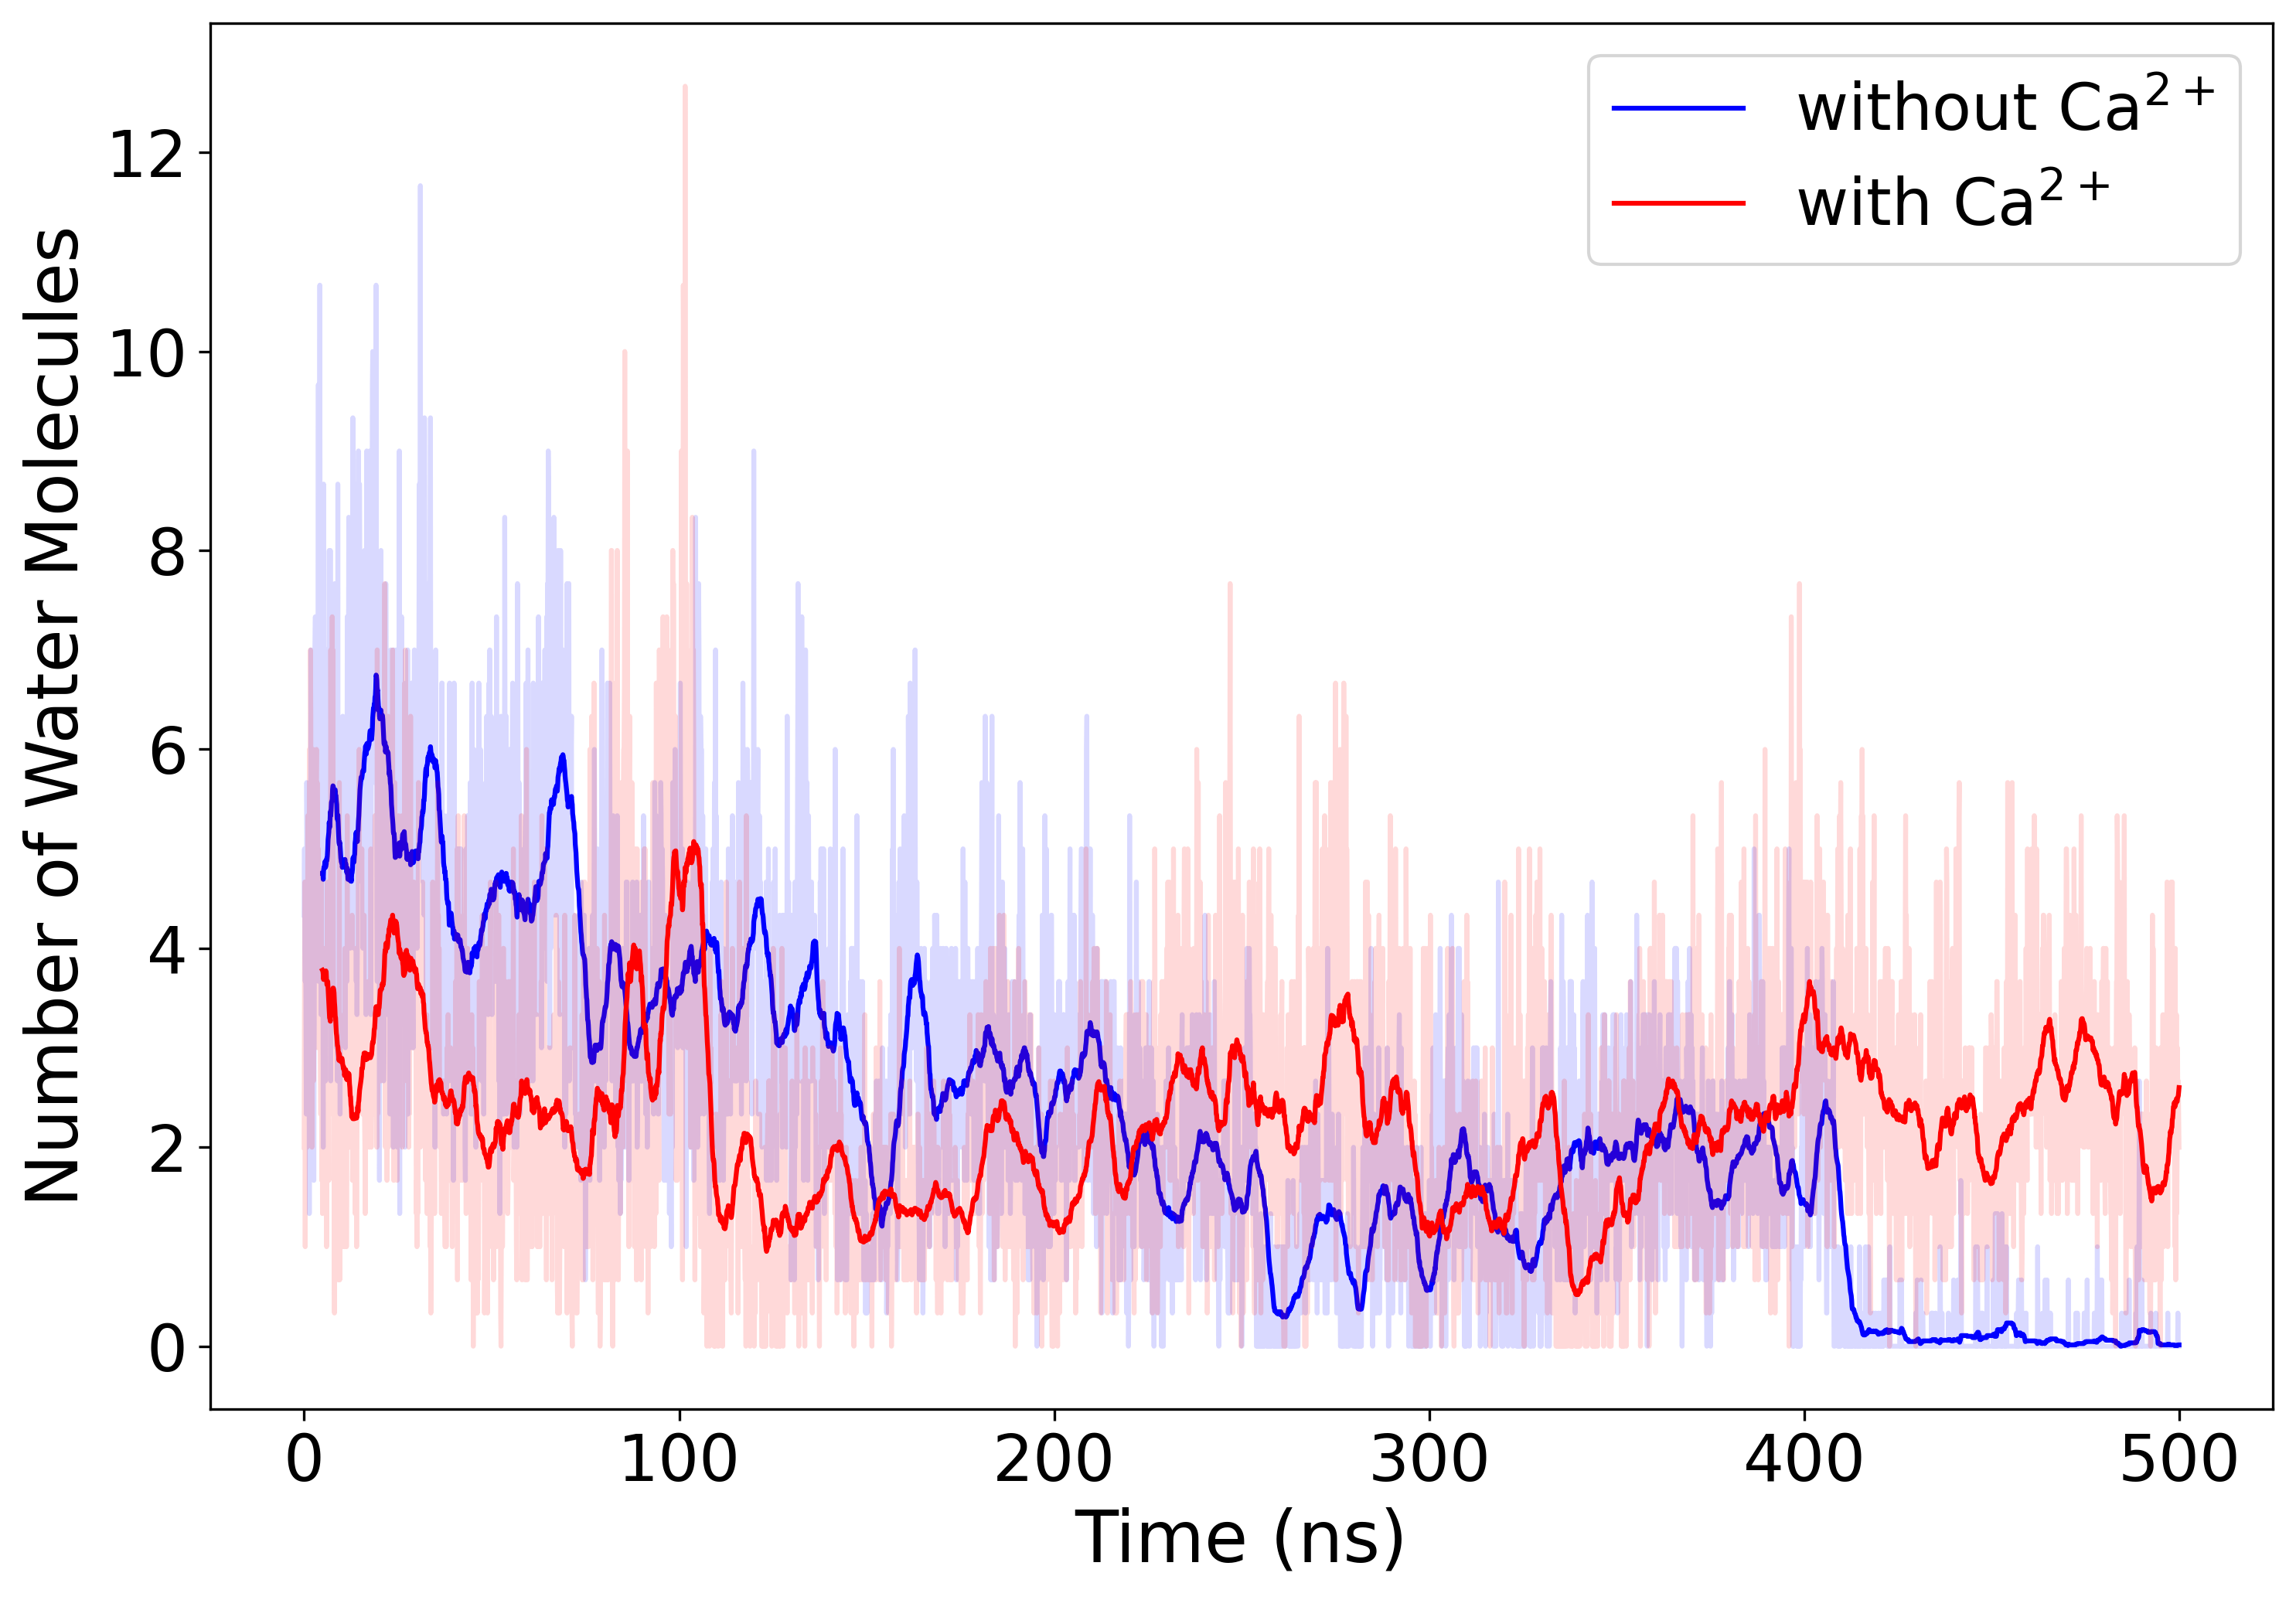

In [78]:
plot_water_molecules(df_five,df_five_ca,"Number of water molecules (+5-state) with and without Ca (rolling).png")

In [54]:
selection = "resname TIP3 and prop z<55 and prop z>27 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"
selection_ca = "resname TIP3 and prop z<75 and prop z>47 and (around 3 resid 8 and resname ASN or around 3 resid 11 and resname LEU or around 3 resid 14 and resname LEU or around 3 resid 18 and resname VAL or around 3 resid 21 and resname LEU or around 3 resid 25 and resname ALA)"

df_neutral = calculate_water(u_neutral,'df_neutral',selection)
df_neutral_ca = calculate_water(u_neutral_ca,'df_neutal_ca',selection_ca)

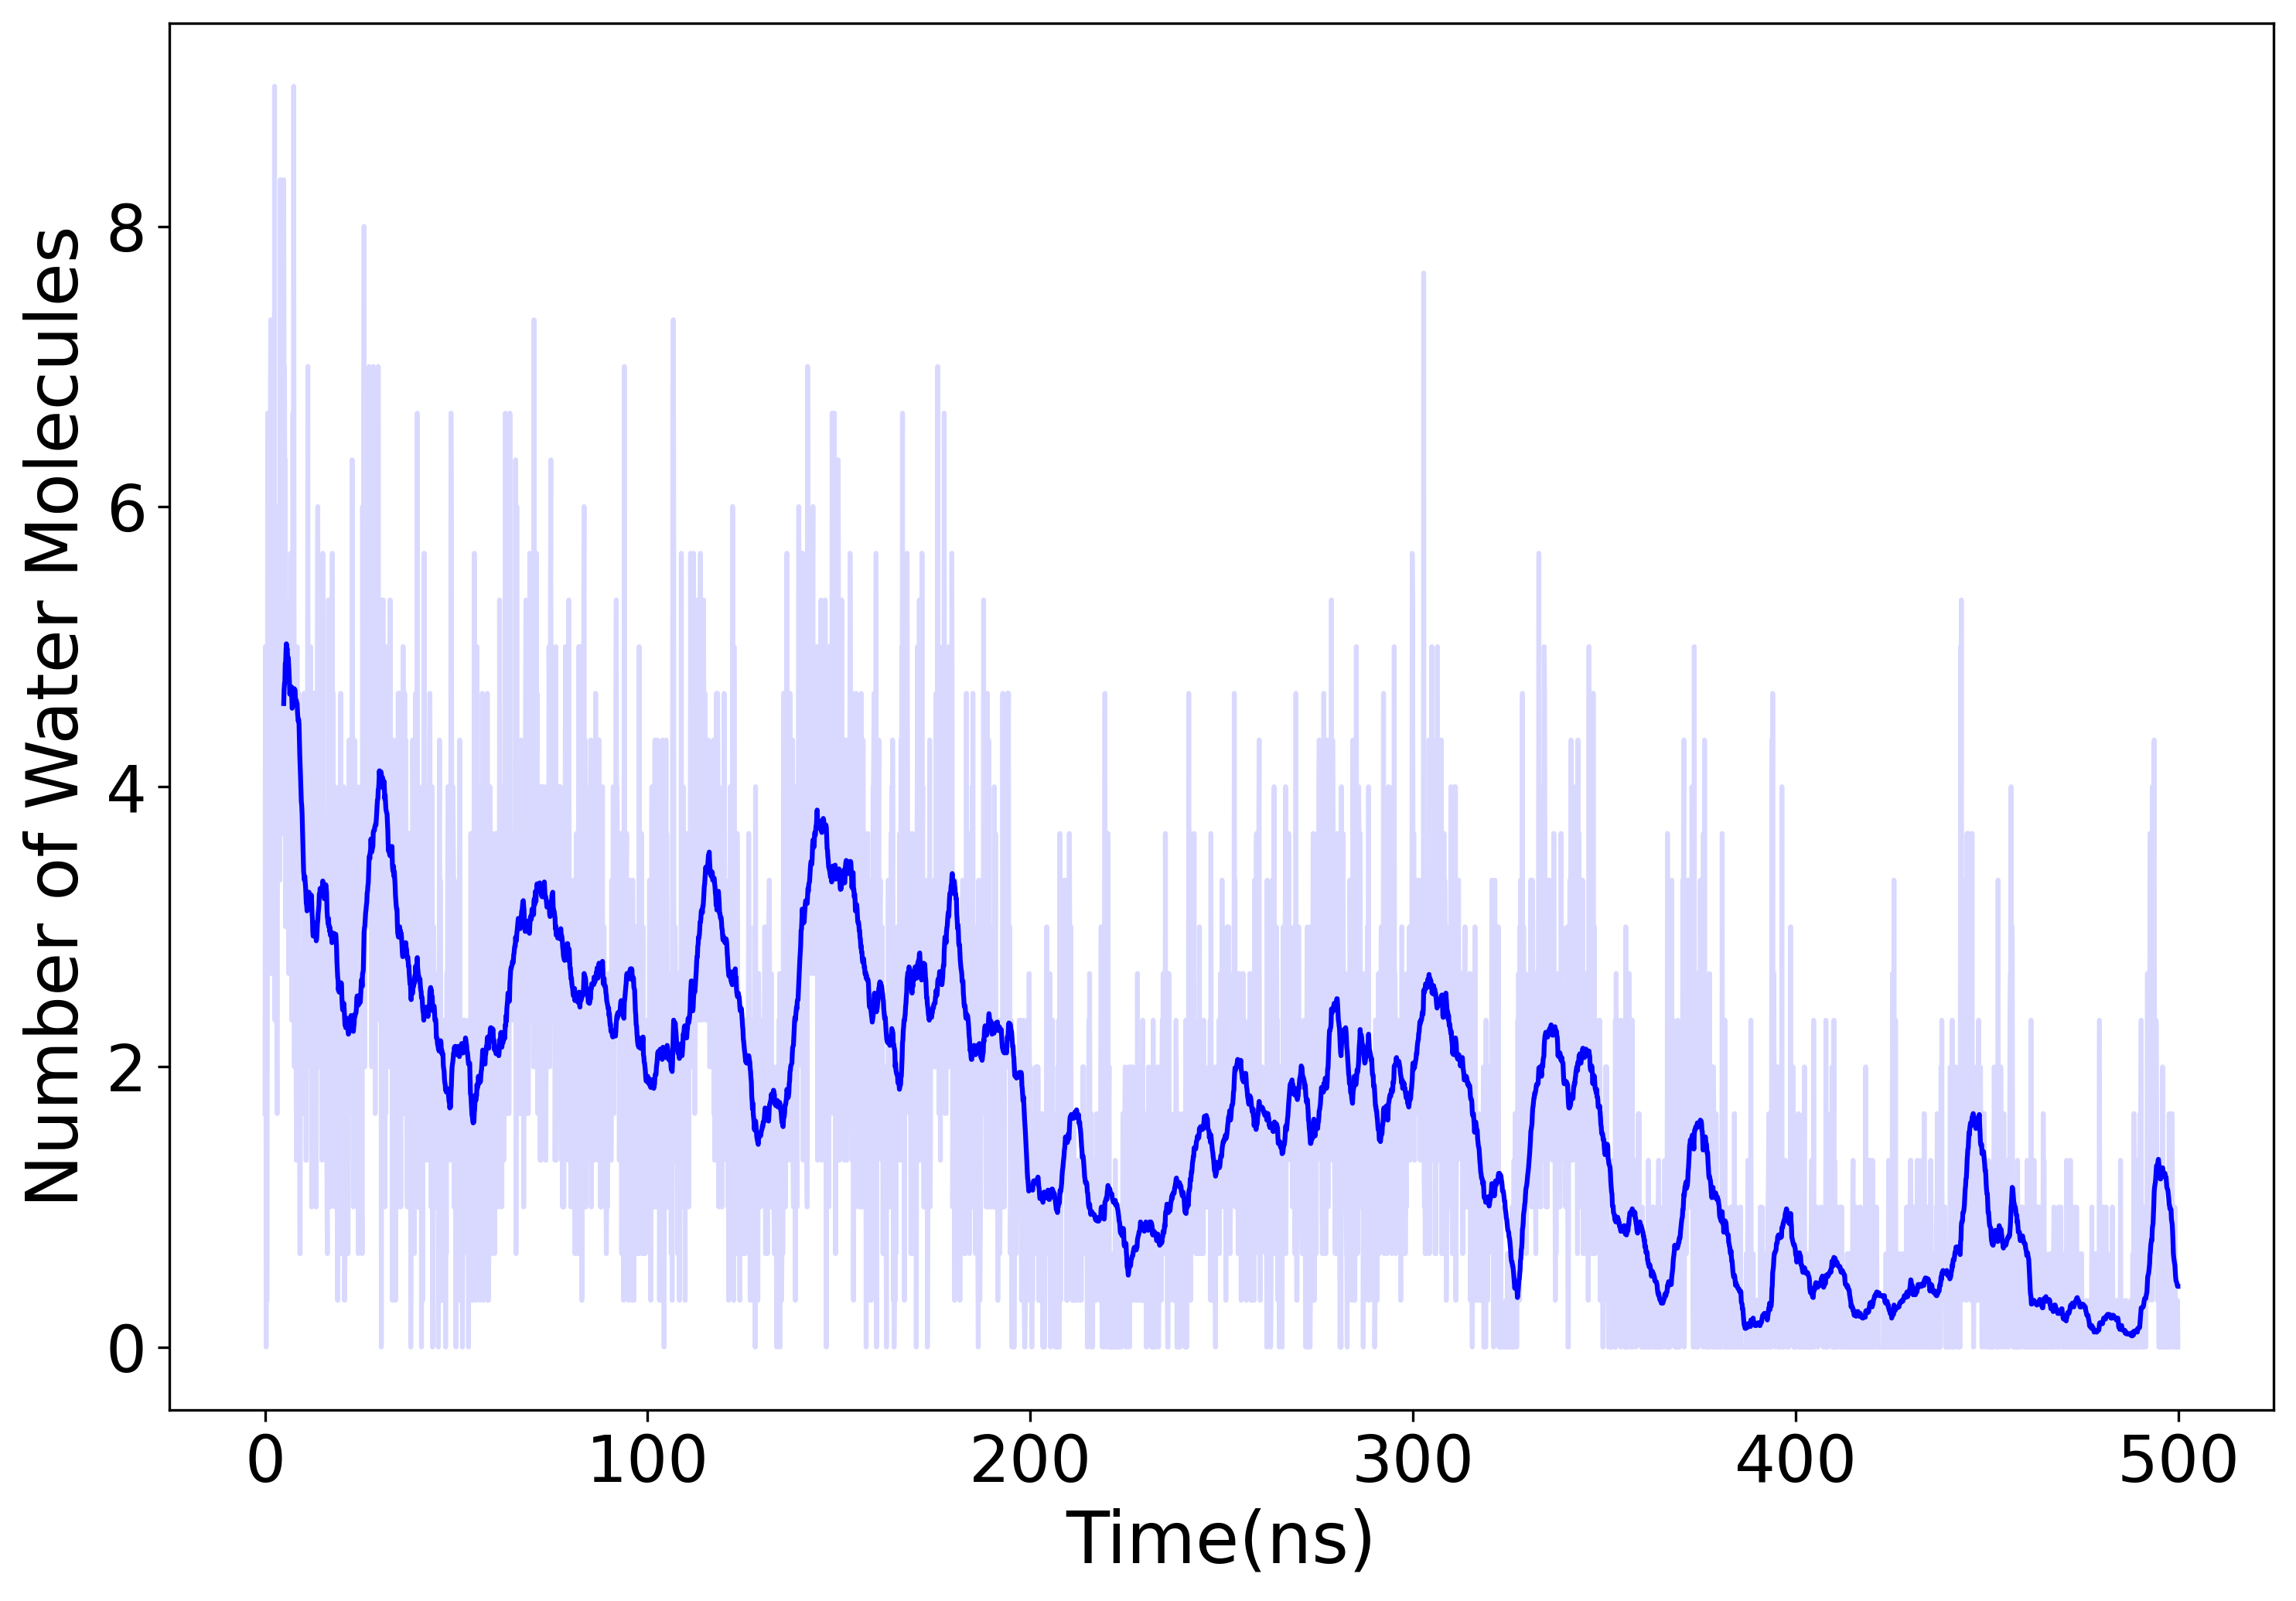

In [80]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_neutral['Timeframe'][:5000],df_neutral['Water molecules'][:5000],color="blue",alpha=0.15)
rolling_avg = df_neutral['Water molecules'].rolling(window=50).mean()
plt.plot(df_neutral['Timeframe'][:5000],rolling_avg[:5000],color="blue",label=r"without Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Number of water molecules (Neutral-state) without Ca 500ns with 3A (rolling).png",dpi=300)
plt.show()

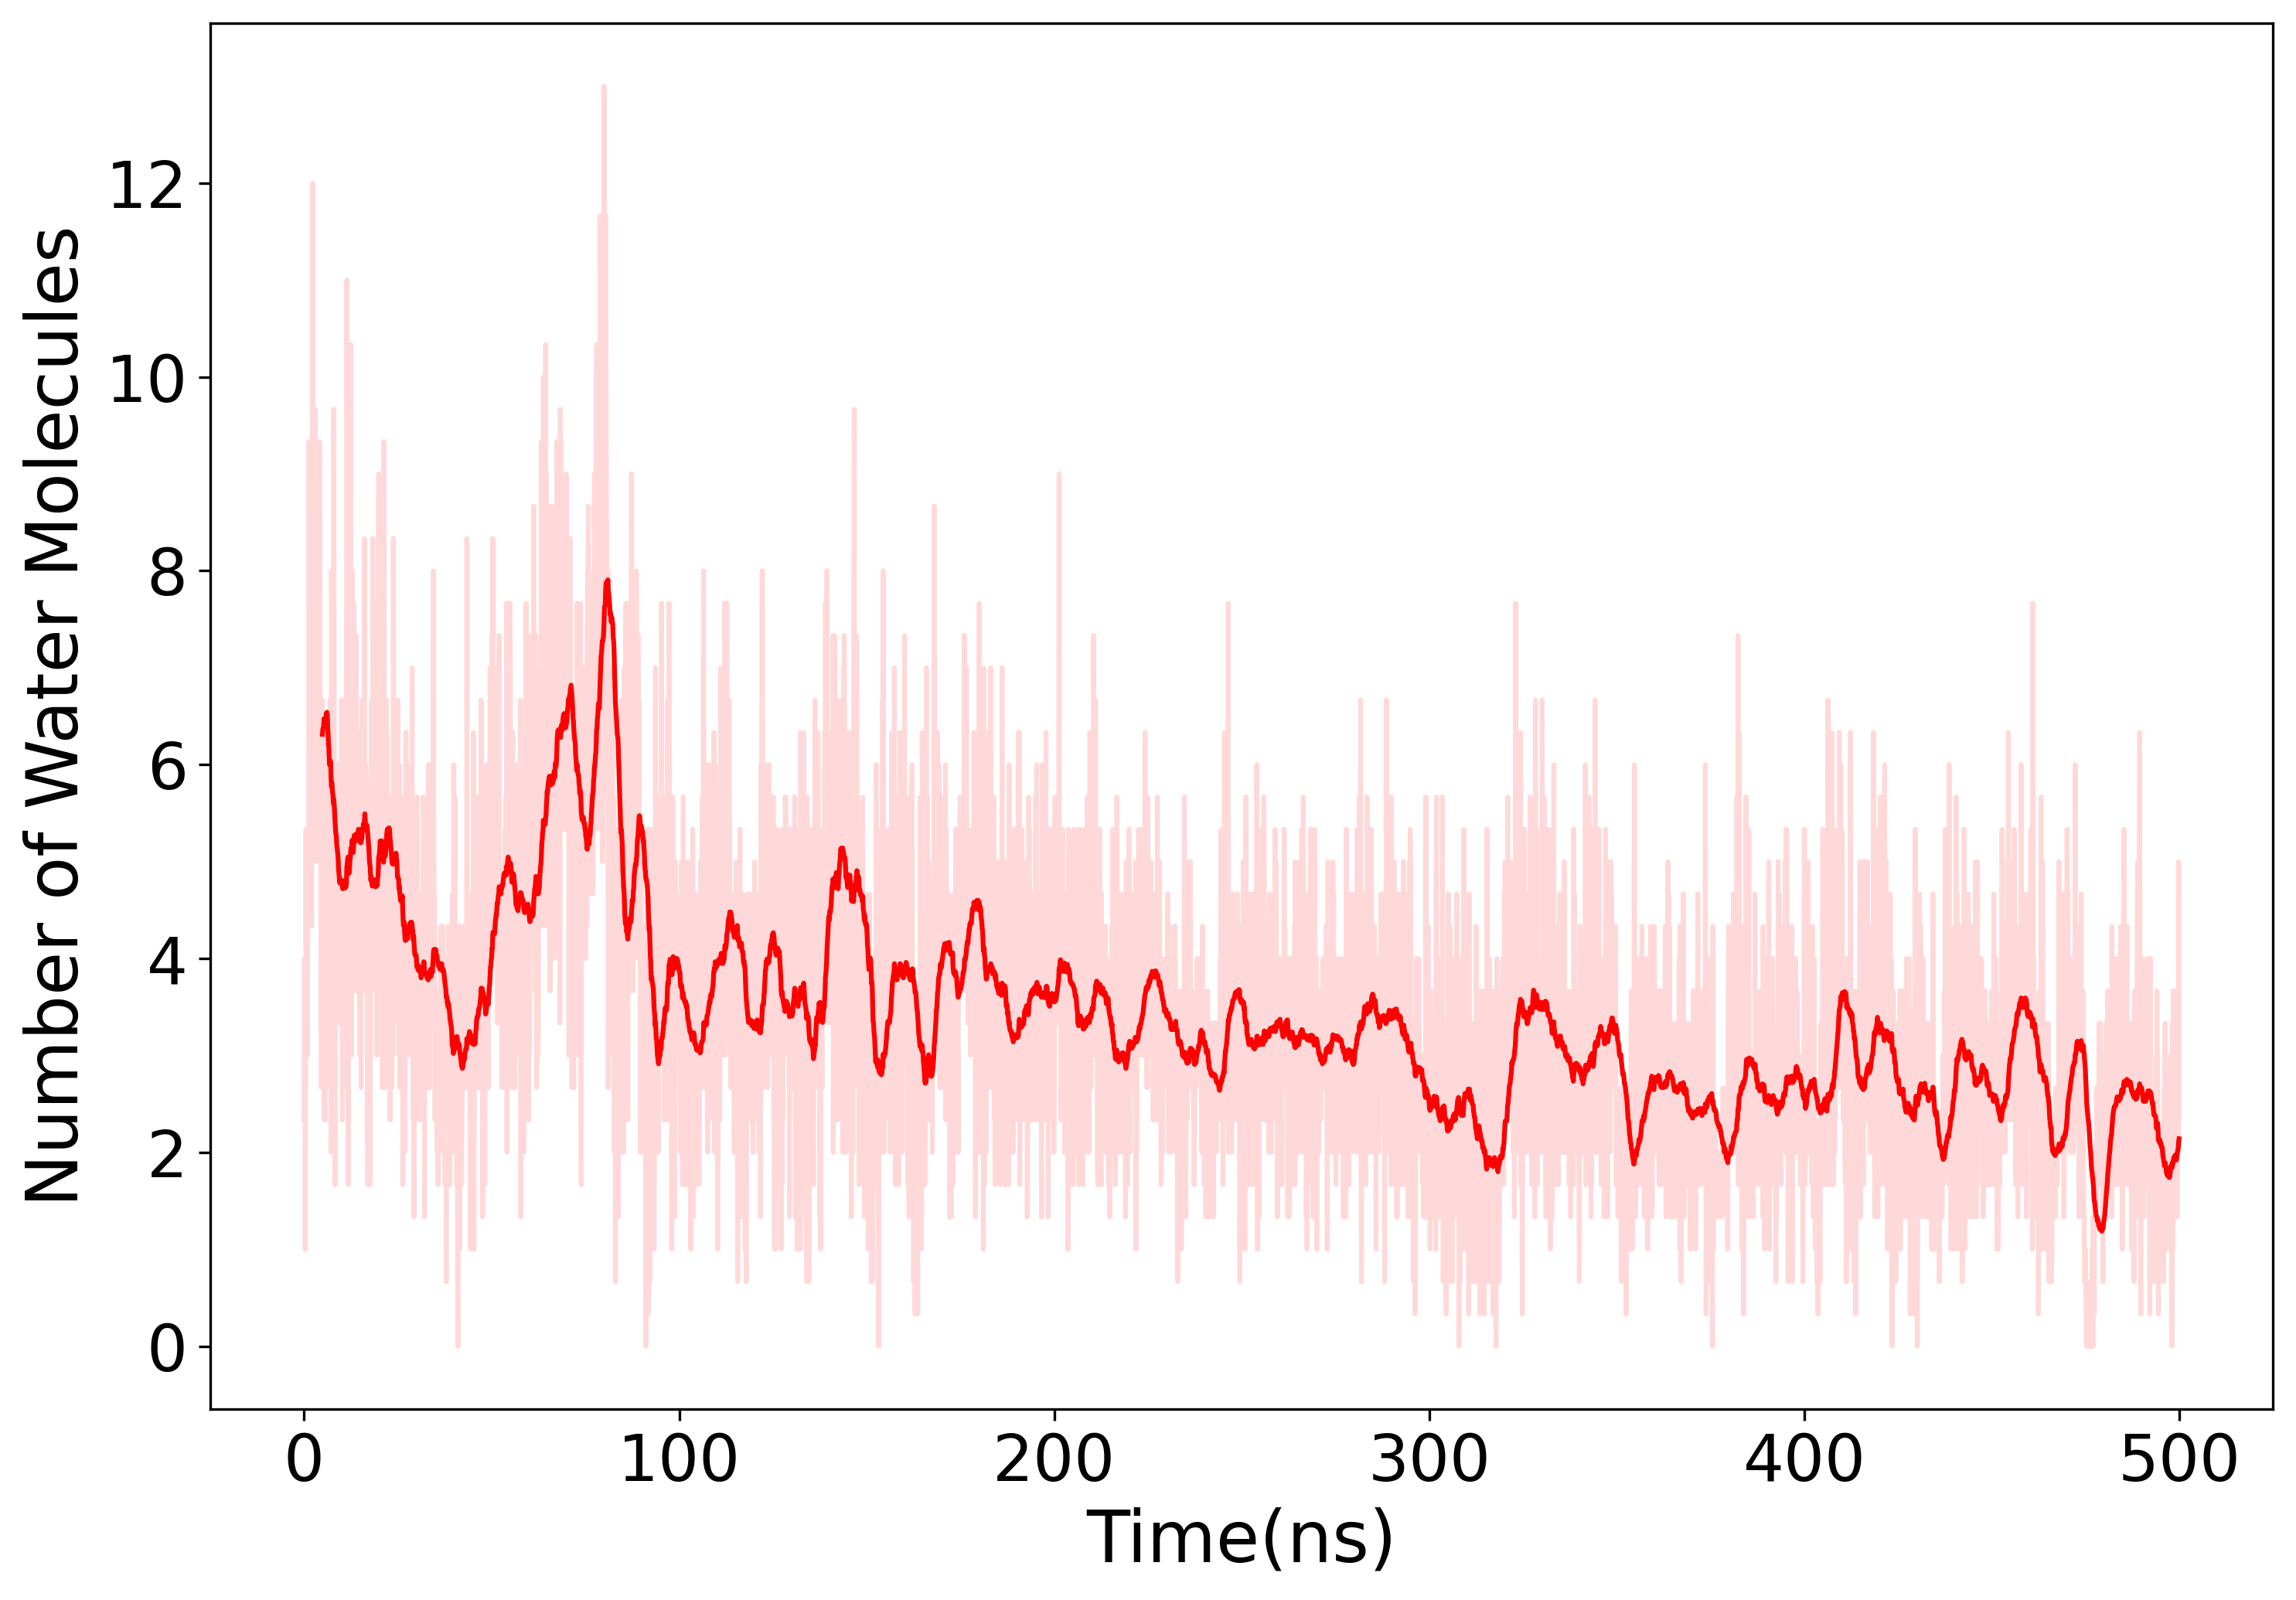

In [82]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_neutral_ca['Timeframe'][:5000],df_neutral_ca['Water molecules'][:5000],color="red",alpha=0.15)
rolling_avg = df_neutral_ca['Water molecules'].rolling(window=50).mean()
plt.plot(df_neutral_ca['Timeframe'][:5000],rolling_avg[:5000],color="red",label=r"with Ca$^{2+}$")
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Number of water molecules (Neutral-state) with Ca 500ns with 3A (rolling).png",dpi=300)
plt.show()

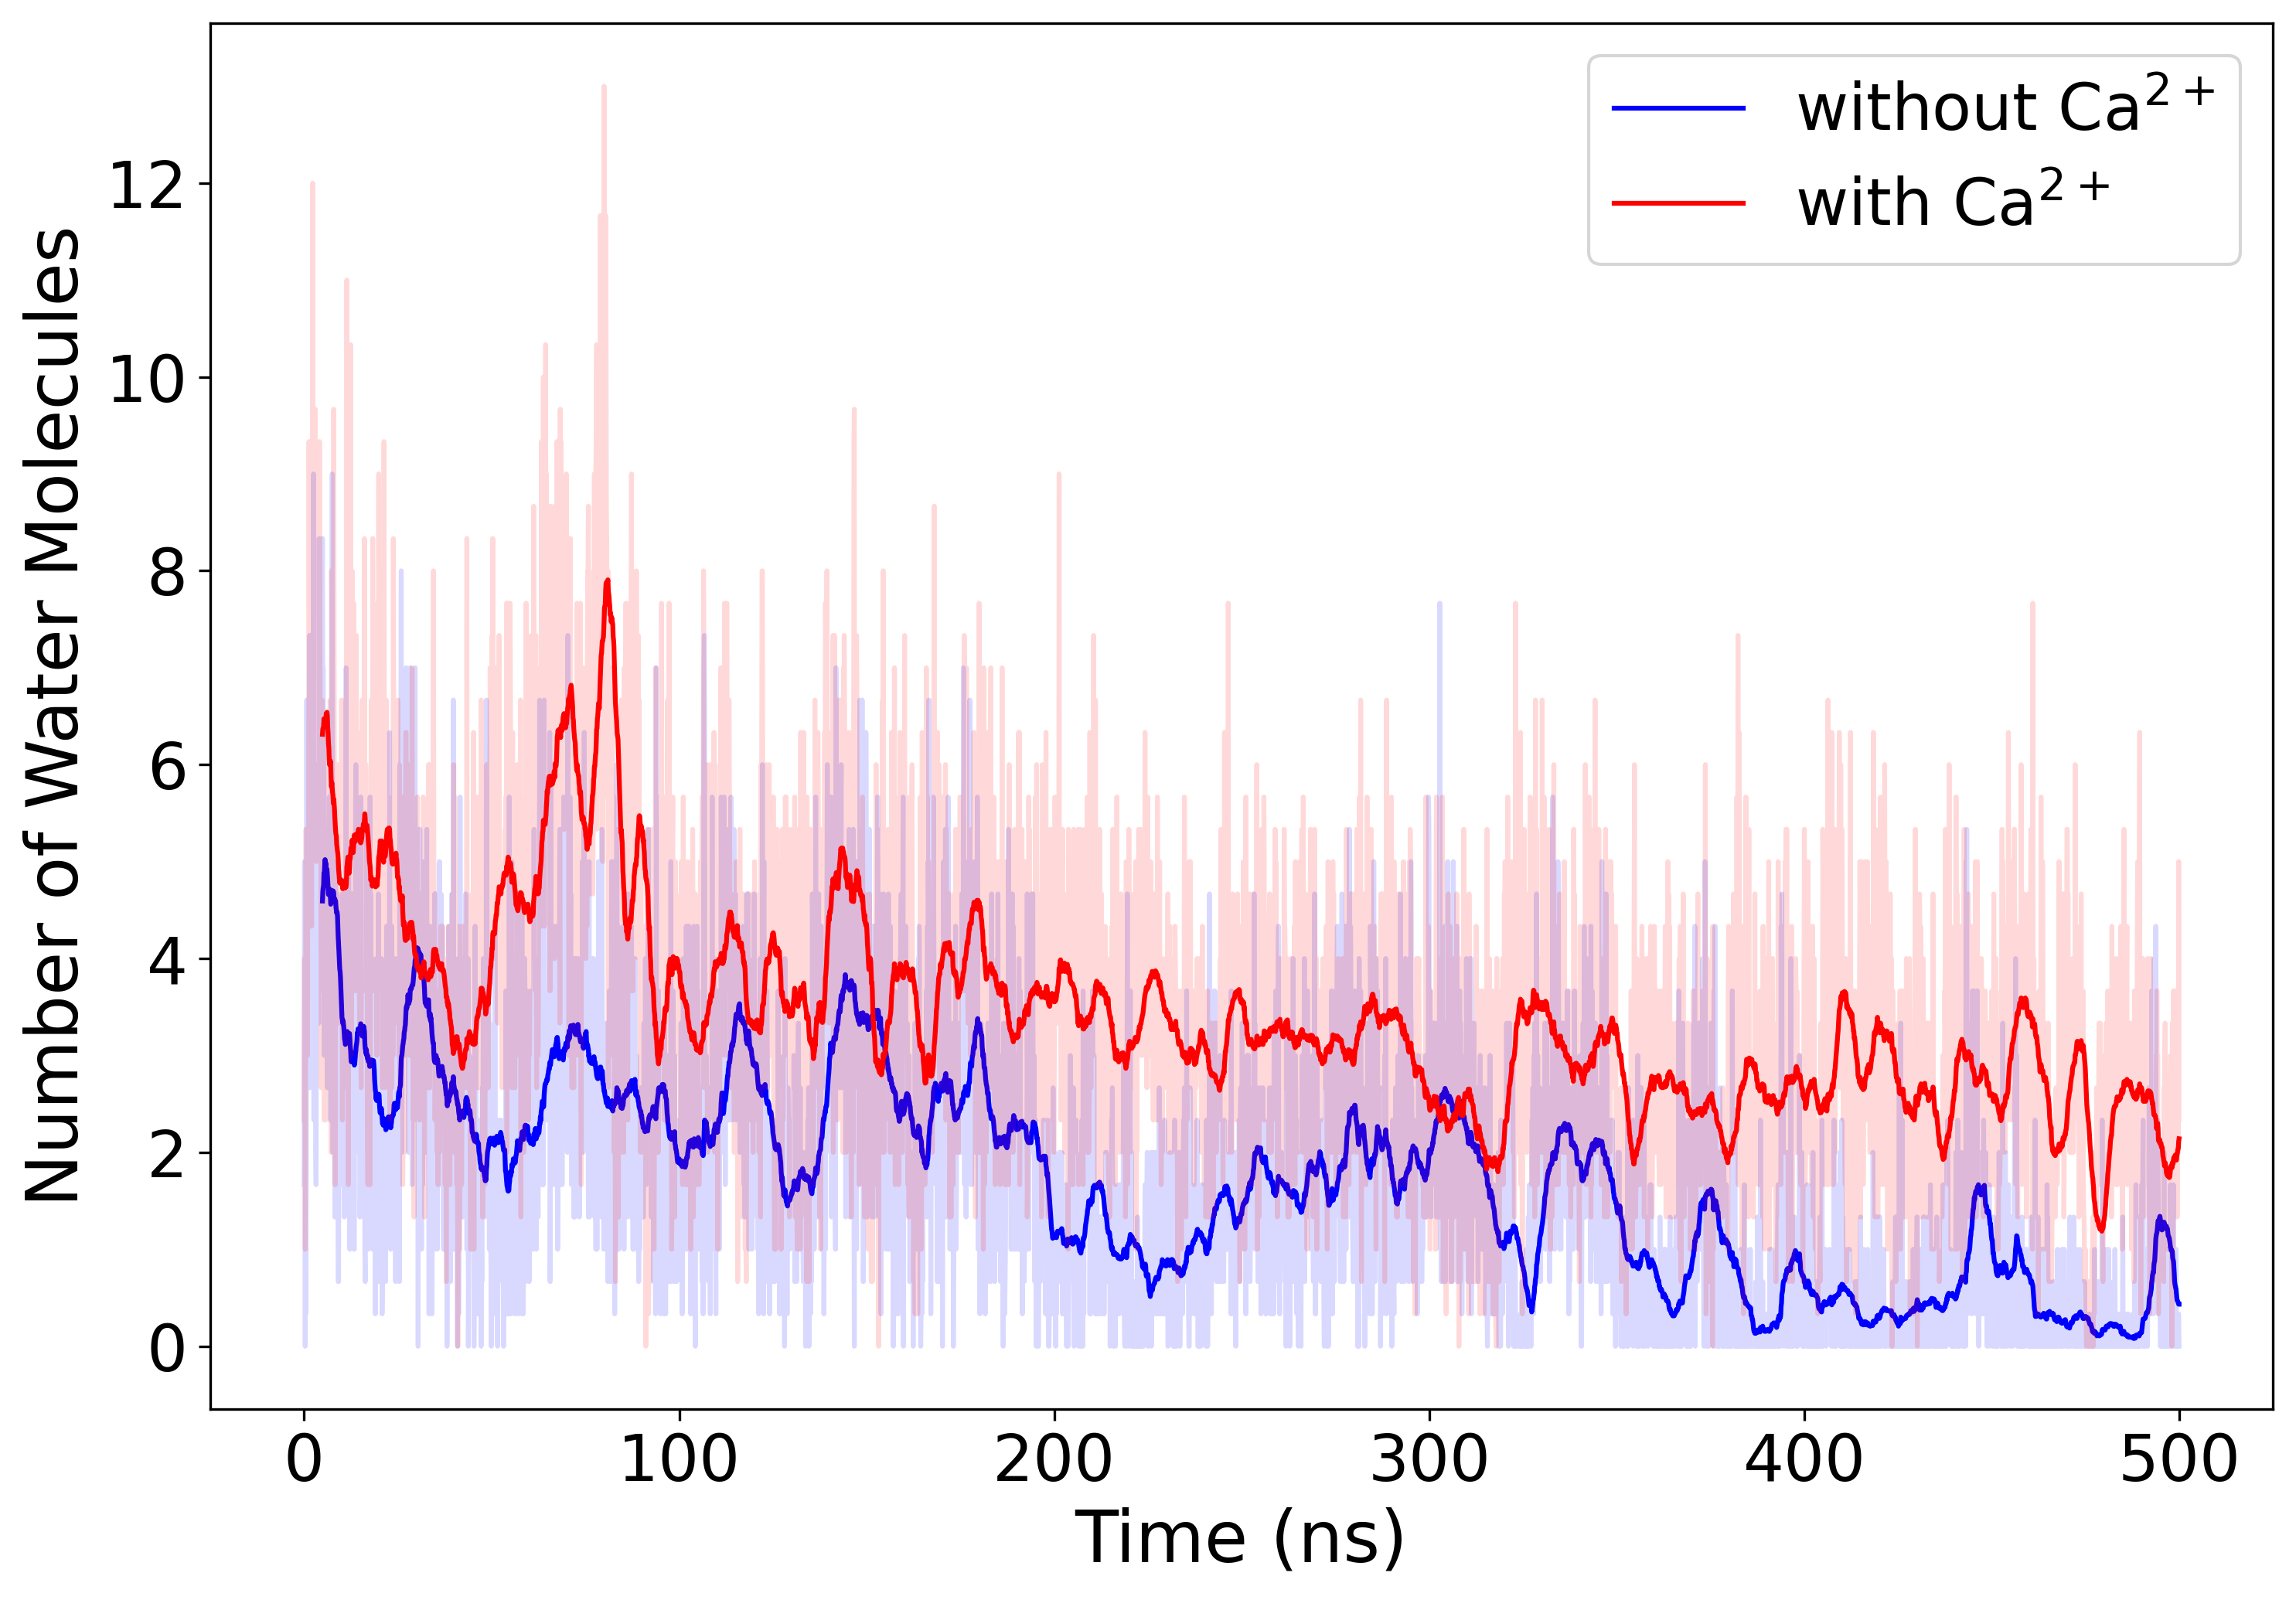

In [84]:
plot_water_molecules(df_neutral,df_neutral_ca,"Number of water molecules (Neutral-state) with and without Ca (rolling).png")

In [109]:
print(np.std(df_five_ca['Water molecules']))

1.3355798075440275


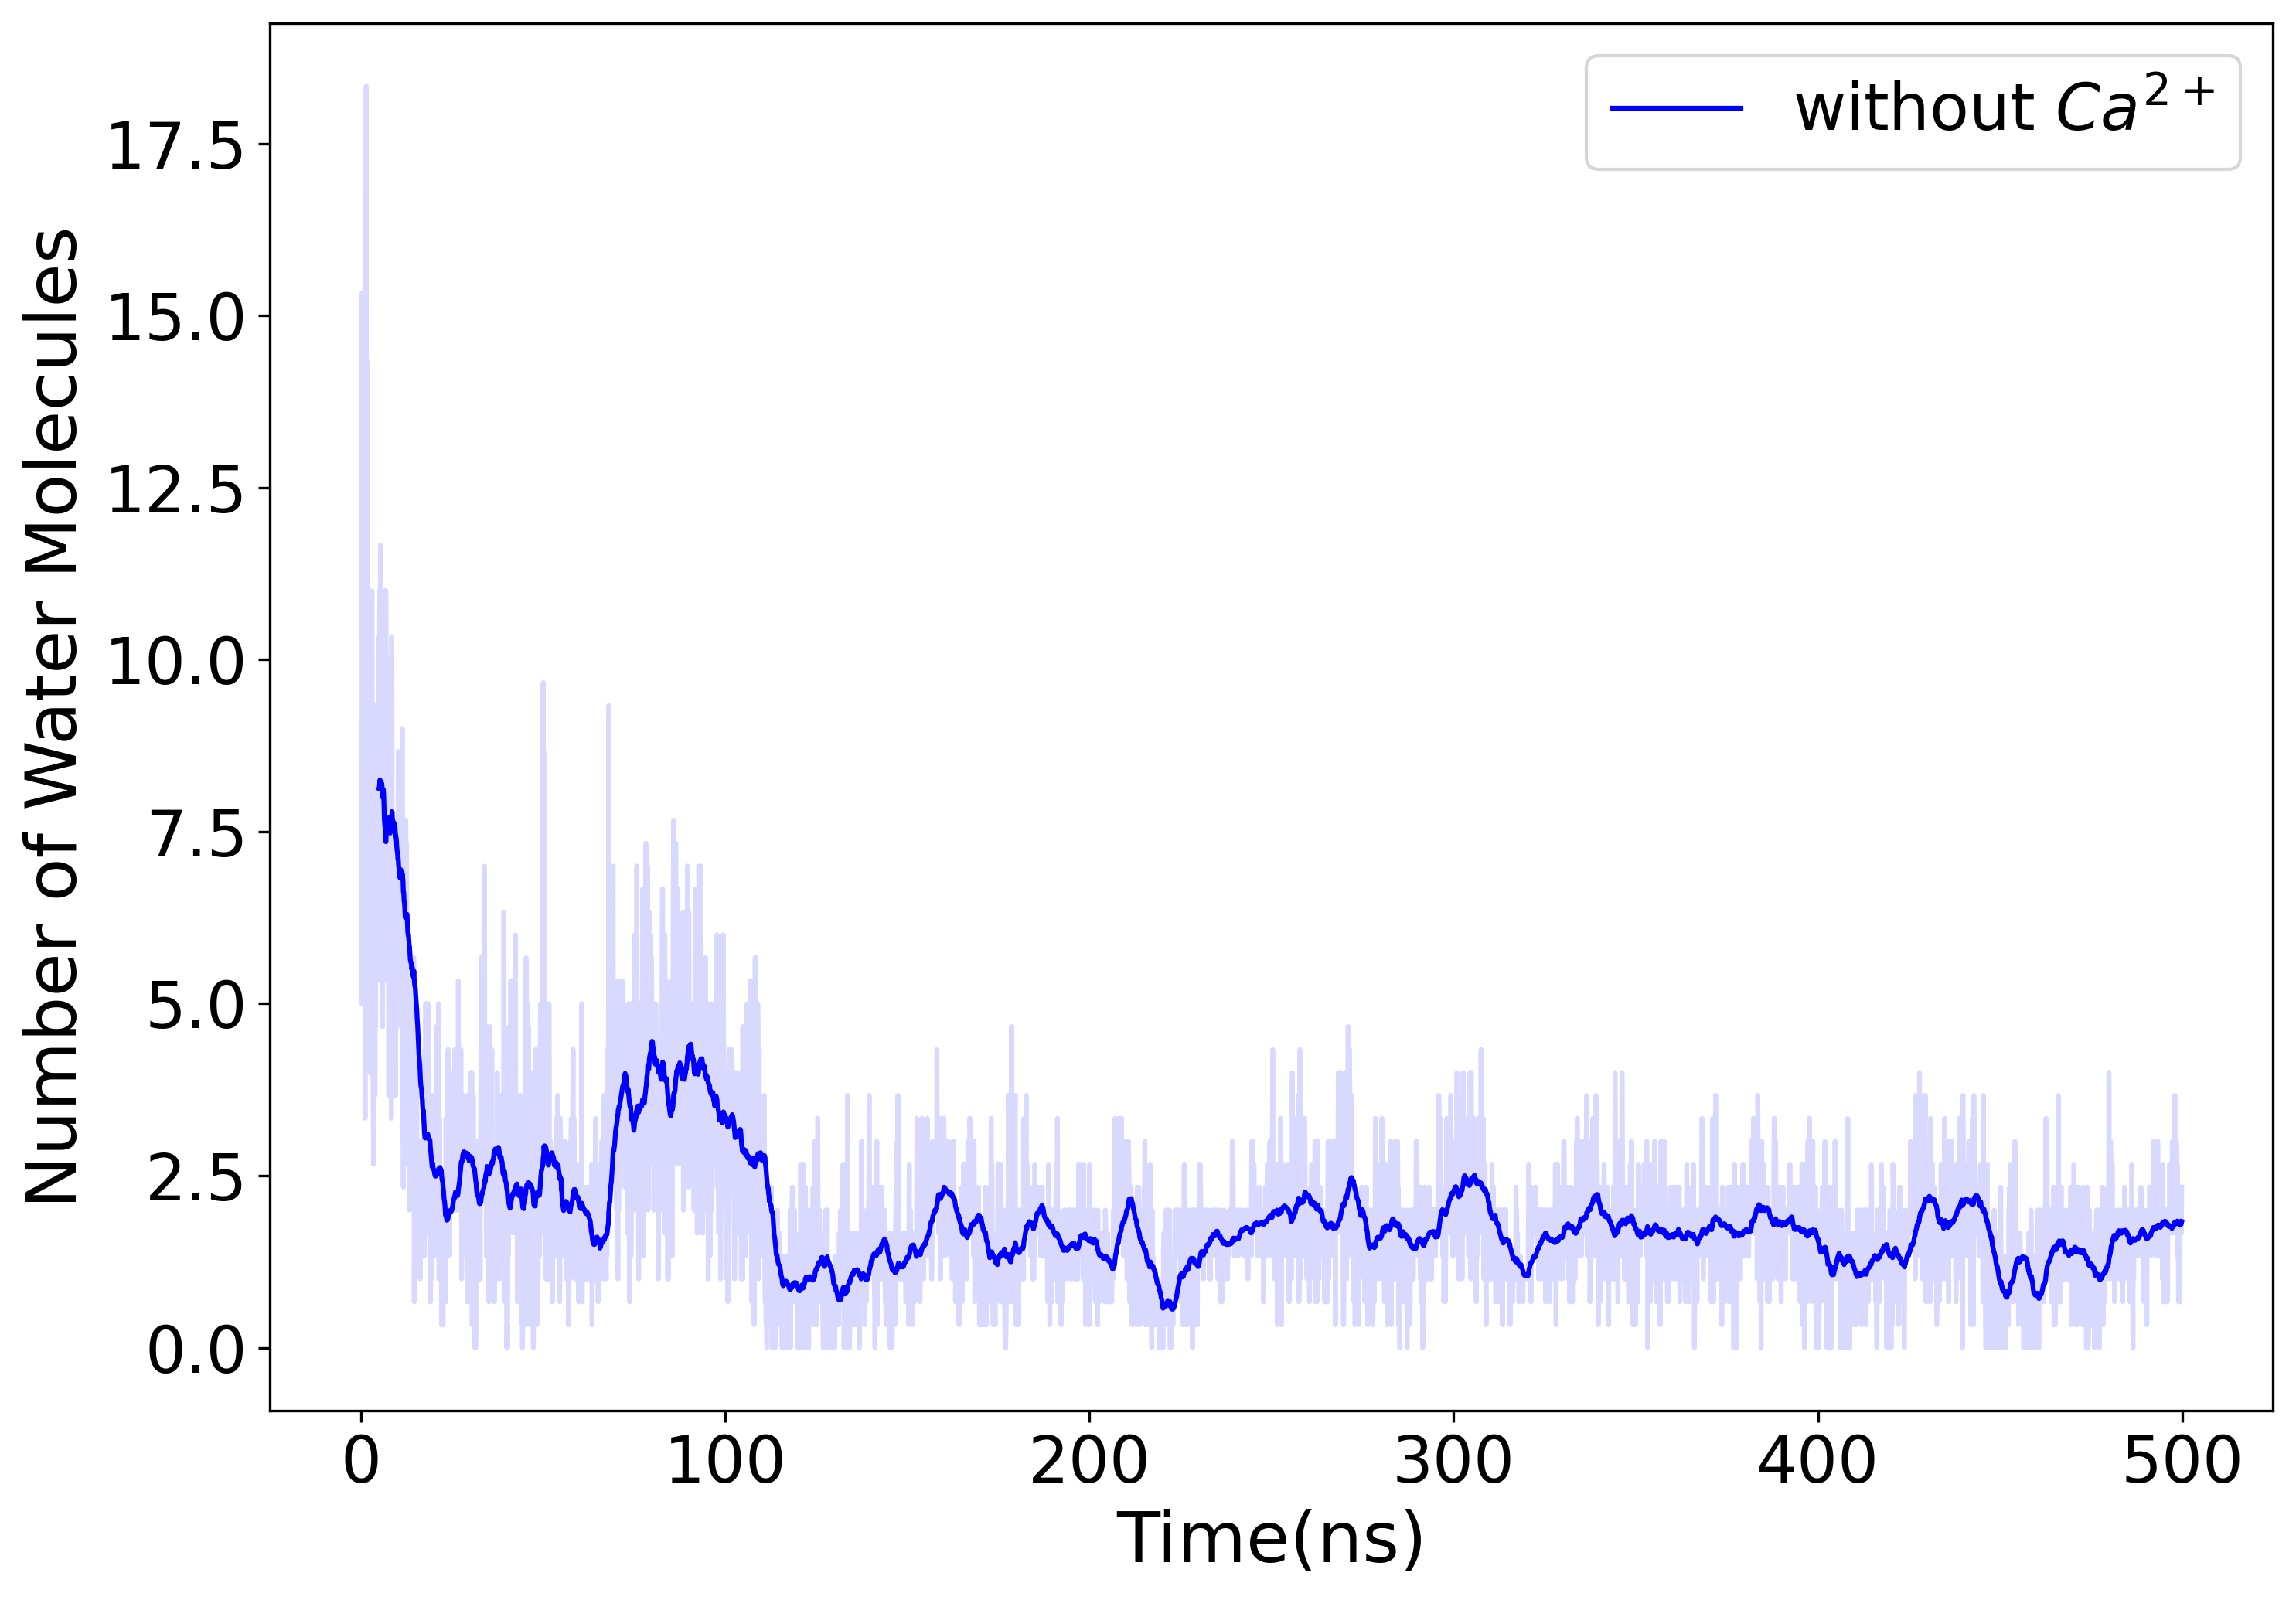

In [94]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_two['Timeframe'][:5000],df_two['Water molecules'][:5000],color="blue",alpha=0.15)
rolling_avg = df_two['Water molecules'].rolling(window=50).mean()
#rolling_avg_ca = df_neutral_ca['Water molecules'].rolling(window=50).mean()
plt.plot(df_two['Timeframe'][:5000],rolling_avg[:5000],color="blue",label=r"without $Ca^{2+}$")
#plt.plot(df_neutral_ca['Timeframe'][:5000],df_neutral_ca['Water molecules'][:5000],color="red",alpha=0.15)
#plt.plot(df_neutral_ca['Timeframe'][:5000],rolling_avg_ca[:5000],color="red",label=r"with $Ca^{2+}$")
#plt.axis([0,i,0,max(y)])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.legend(fontsize=20)
plt.savefig("Number of water molecules (+2-state) without Ca 500ns with 3A (rolling).pdf",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

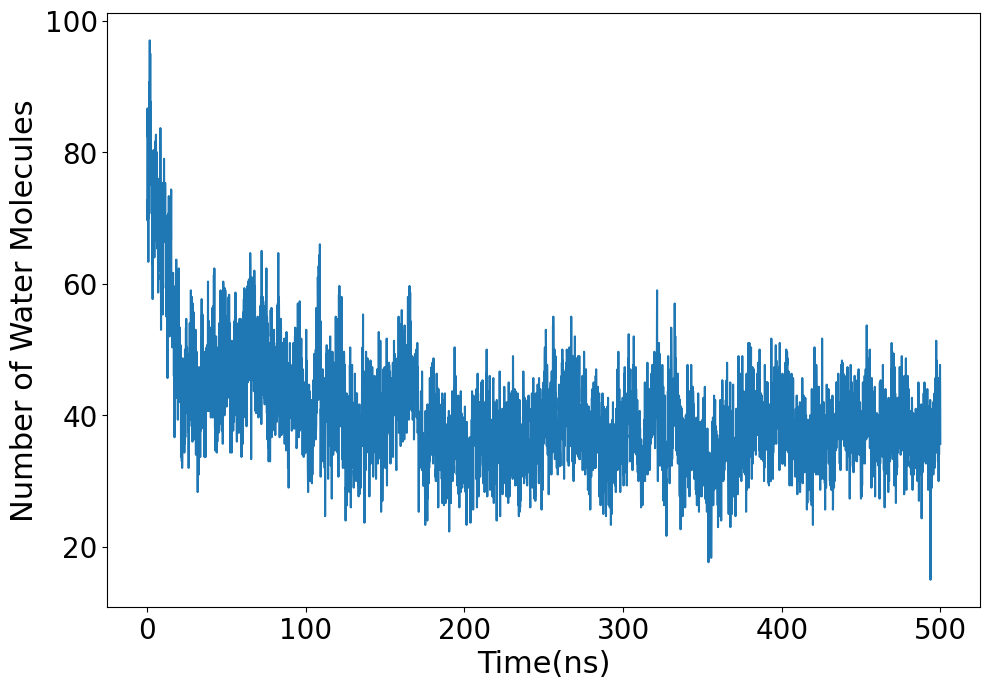

In [67]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_two['Timeframe'][:5000],df_two['Water molecules'][:5000])
#plt.axis([0,i,0,max(y)])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (+2-state) without Ca 500ns with 3A.png",dpi=300)
plt.show()

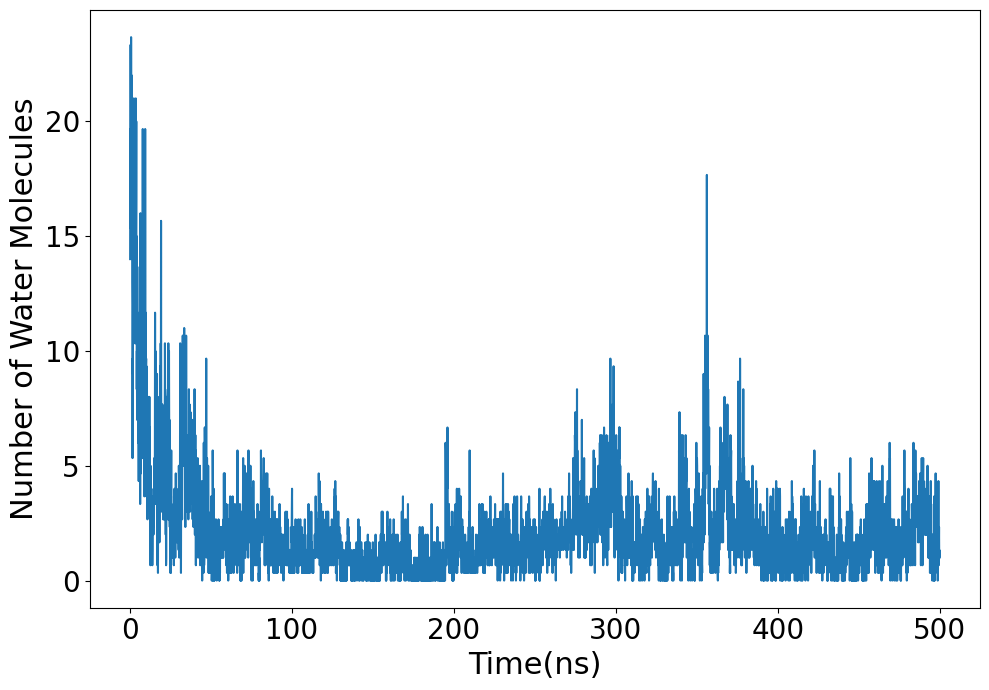

In [68]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_two_ca['Timeframe'][:5000],df_two_ca['Water molecules'][:5000])
#plt.axis([0,i,0,max(y)])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (+2-state) with Ca 500ns with 3A.png",dpi=300)
plt.show()

In [69]:
df_four = calculate_water(u_four, 'df_four')
df_four_ca = calculate_water(u_four_ca, 'df_four_ca')

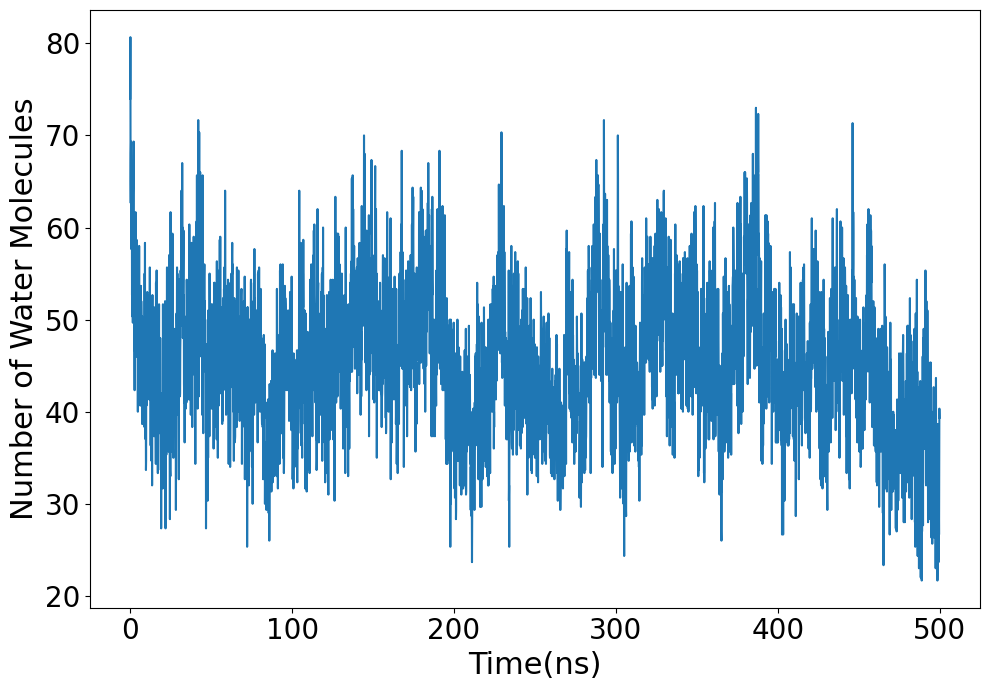

In [70]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_four['Timeframe'][:5000],df_four['Water molecules'][:5000])
#plt.axis([0,i,0,max(y)])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (+4-state) without Ca 500ns with 3A.png",dpi=300)
plt.show()

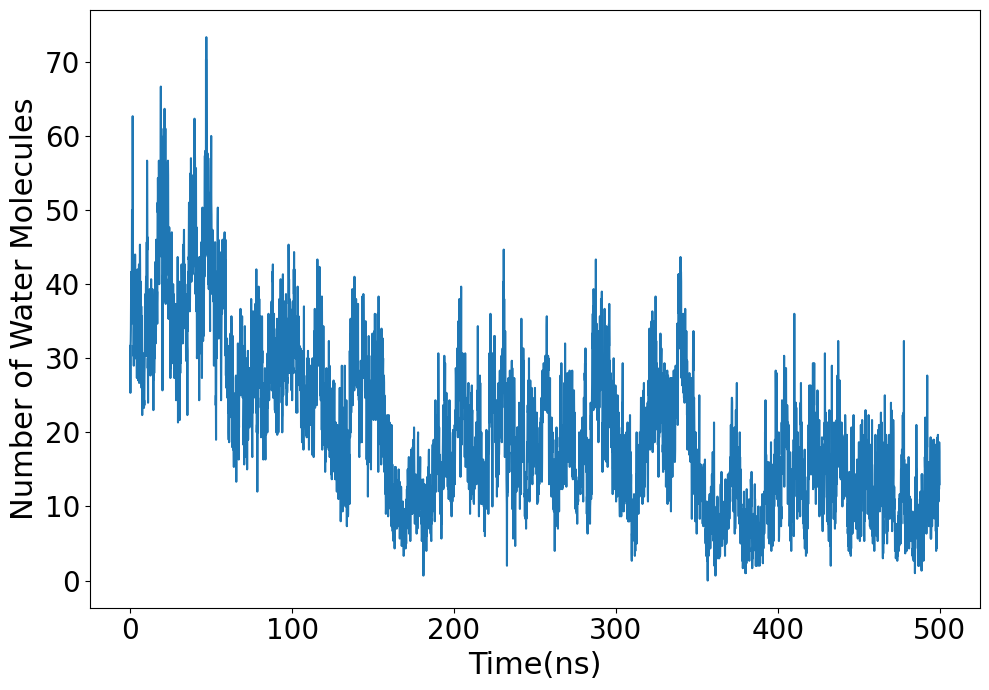

In [71]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_four_ca['Timeframe'][:5000],df_four_ca['Water molecules'][:5000])
#plt.axis([0,i,0,max(y)])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (+4-state) with Ca 500ns with 3A.png",dpi=300)
plt.show()

In [72]:
df_five = calculate_water(u_five,'df_five')
df_five_ca = calculate_water(u_five_ca,'df_five_ca')

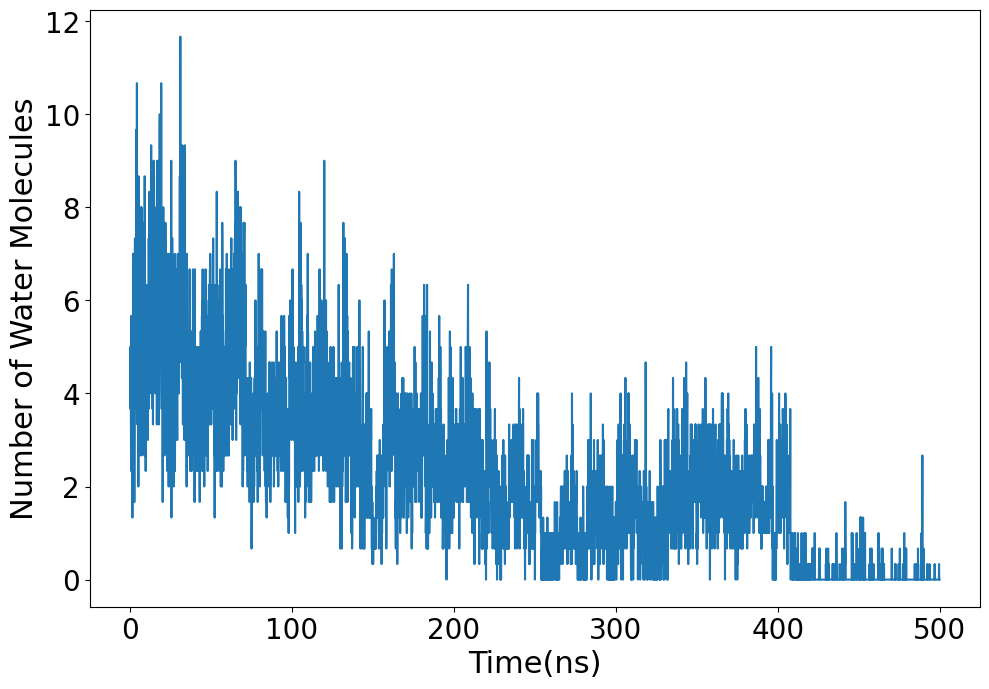

In [73]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_five['Timeframe'][:5000],df_five['Water molecules'][:5000])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (+5-state) without Ca 500ns with 3A.png",dpi=300)
plt.show()

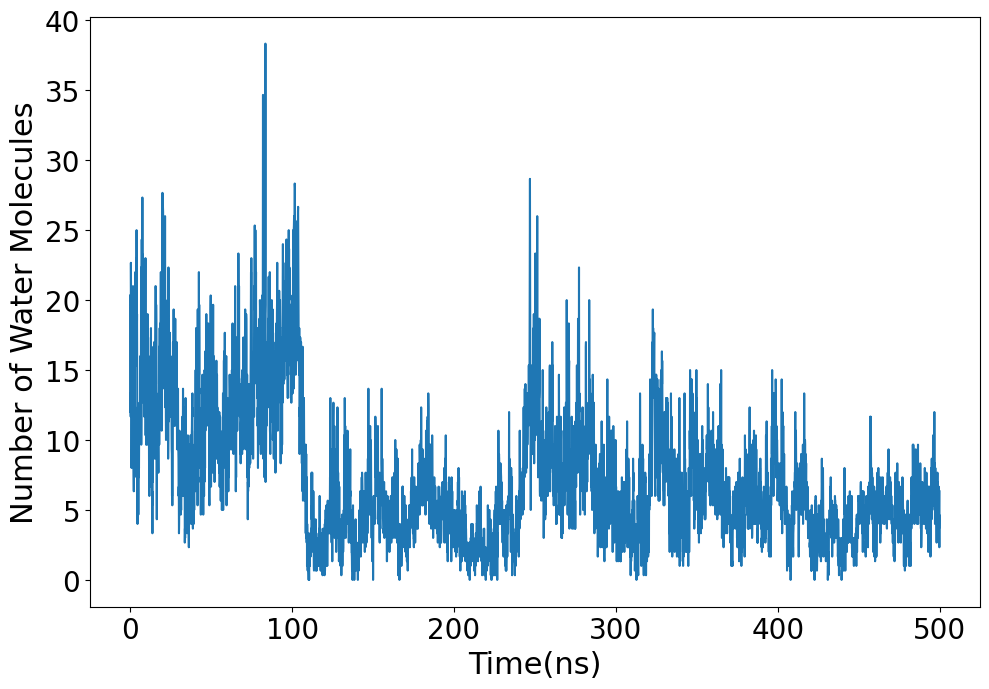

In [74]:
fig,ax = plt.subplots(figsize = (10,7))
ax.plot(df_five_ca['Timeframe'][:5000],df_five_ca['Water molecules'][:5000])
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Number of Water Molecules", fontsize=22)
plt.yticks(fontsize=20)
fig.tight_layout()
ax.figure.savefig("Number of water molecules (+5-state) with Ca 500ns with 3A.png",dpi=300)
plt.show()